# Data description

In [4]:

import os
import sys
import importlib
from importlib import reload 
from dataclasses import dataclass, field, fields
from itertools import compress
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from cycler import cycler

import scipy
import scipy.io as sio
from scipy import signal
from scipy.signal import spectrogram, hann, butter, filtfilt, freqz
from scipy import stats
from scipy.stats import norm
from scipy.stats import ttest_ind

import seaborn as sns
import pingouin as pg
import itertools
from itertools import combinations
from statannotations.Annotator import Annotator
import statsmodels.api as sm
import statsmodels.formula.api as smf
from patsy import dmatrices
import plotly.express as px

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold, GridSearchCV
from sklearn.metrics import classification_report

# import openpyxl
# from openpyxl import Workbook, load_workbook
# import xlrd
import pickle
import json
import csv

#mne
import mne_bids
import mne
from mne.time_frequency import tfr_morlet 
from mne.stats import permutation_cluster_test


# TODO: add README file: 
# pip install pingouin
# pip install statannotations
# pip install fooof

/Users/jenniferbehnke/anaconda3/envs/bssu/lib/python3.11/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.5.5.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


In [397]:
jennifer_user_path = os.getcwd()
while jennifer_user_path[-14:] != 'jenniferbehnke':
    jennifer_user_path = os.path.dirname(jennifer_user_path)

# directory to this Repository
project_path = os.path.join(jennifer_user_path, 'code', 'BetaSenSightLongterm', 'BetaSenSightLongterm')
sys.path.append(project_path)

os.chdir(project_path)

import src.bssu.utils.find_folders as find_folders
importlib.reload(find_folders)

# import PyPerceive

project_path = find_folders.chdir_repository("Py_Perceive")

from PerceiveImport.classes import (
    main_class, modality_class, metadata_class,
    session_class, condition_class, task_class,
    contact_class, run_class
)

import PerceiveImport.methods.load_rawfile as load_rawfile
import PerceiveImport.methods.find_folders as PyPerceive_find_folders
import PerceiveImport.methods.metadata_helpers as metaHelpers

# import meet

project_path = find_folders.chdir_repository("meet")

import meet as meet

# import all functions from BetaSenSightLongterm
project_path = find_folders.chdir_repository("BetaSenSightLongterm")

# tfr, processing
import src.bssu.tfr.BSSuPsd as BSSuPsd
import src.bssu.tfr.FastFourierPSD as FFpsd
import src.bssu.tfr.fooof_fit as fooof_fit
import src.bssu.tfr.fooof_peak_analysis as fooof_peaks

# bipolar Channel Analysis
import src.bssu.bipolar.power_spectra_plots as power_spectra_plots
import src.bssu.bipolar.PeakFrequencies_PSD as PeakFrequency_psd
import src.bssu.bipolar.BIP_channelGroups as BIP_channelGroups
import src.bssu.bipolar.BIP_perChannelAnalysis as BIP_perChannel


# monopolar Referencing
import src.bssu.monopolar.MonoRef_JLB as MonoRefJLB
import src.bssu.monopolar.GroupMonopolarPSD as groupMonopol
import src.bssu.monopolar.monoRef_weightPsdAverageByCoordinateDistance as MonoRefWeightedCoordinateDistance
import src.bssu.monopolar.externalized_lfp as externalized
import src.bssu.monopolar.monopol_method_comparison as monopol_comparison
import src.bssu.monopolar.bssu_contacts_maximal_beta as bssu_contacts
import src.bssu.monopolar.monoRef_Strelow as detec_strelow

# Ranking Order
import src.bssu.ranking.HighestRankedChannelPSD as highestRank
import src.bssu.ranking.monopolPSDaverage_withinSubject as PSDaverageMonopol
import src.bssu.ranking.BIPchannelGroups_ranks as BIP_ranks
import src.bssu.ranking.Permutation_rankings as Permute_ranks
import src.bssu.ranking.beta_rank_longitudinal_changes as beta_rank_change


# Clinical stimulation parameters
import src.bssu.stimulation.activeStimulationContacts as activeStimContacts

# utility functions
import src.bssu.utils.loadResults as loadResults
import src.bssu.utils.find_folders as find_folders
import src.bssu.utils.writeGroupDataframes as writeGroupDF
import src.bssu.utils.load_data_files as load_data
import src.bssu.utils.monopol_comparison_helpers as mono_comp_helpers
import src.bssu.utils.sub_session_dict as sub_session_dict
import src.bssu.utils.percept_helpers as helpers
# import Classes
from src.bssu.classes import (metadataAnalysis_class, mainAnalysis_class, sessionAnalysis_class, 
                              channelAnalysis_class, featureAnalysis_class, frequencyBand_class)

# import mni coordinates
import src.bssu.mni.load_rotated_coordinates as load_mni

# revision code
import src.bssu.revision.spatial_distribution as spatial_distribution
import src.bssu.revision.peak_analysis as peak_analysis


importlib.reload(BSSuPsd)
importlib.reload(MonoRefJLB)
importlib.reload(loadResults)
importlib.reload(highestRank)
importlib.reload(groupMonopol)
importlib.reload(PSDaverageMonopol)
importlib.reload(FFpsd)
importlib.reload(find_folders)
importlib.reload(metadataAnalysis_class)
importlib.reload(mainAnalysis_class)
importlib.reload(sessionAnalysis_class)
importlib.reload(channelAnalysis_class)
importlib.reload(featureAnalysis_class)
importlib.reload(frequencyBand_class)
importlib.reload(PeakFrequency_psd)
importlib.reload(power_spectra_plots)
importlib.reload(BIP_channelGroups)
importlib.reload(BIP_ranks)
importlib.reload(activeStimContacts)
importlib.reload(Permute_ranks)
importlib.reload(BIP_perChannel)
importlib.reload(load_mni)
importlib.reload(writeGroupDF)
importlib.reload(MonoRefWeightedCoordinateDistance)
importlib.reload(load_data)
importlib.reload(externalized)
importlib.reload(monopol_comparison)
importlib.reload(bssu_contacts)
importlib.reload(mono_comp_helpers)
importlib.reload(detec_strelow)
importlib.reload(beta_rank_change)
importlib.reload(sub_session_dict)
importlib.reload(helpers)
importlib.reload(fooof_fit)
importlib.reload(spatial_distribution)
importlib.reload(fooof_peaks)
importlib.reload(peak_analysis)

Excel file loaded:  patient_metadata.xlsx 
loaded from:  /Users/jenniferbehnke/Dropbox/work/ResearchProjects/Monopolar_power_estimation/data


<module 'src.bssu.revision.peak_analysis' from '/Users/jenniferbehnke/code/BetaSenSightLongterm/BetaSenSightLongterm/src/bssu/revision/peak_analysis.py'>

In [35]:
# load if you want to see complete Dataframes
pd.set_option("display.max_rows", None)

## Steps to write data

In [ ]:
# add single fooof results to group fooof results
# fooof_all_subjects = fooof_fit.add_fooof_singles_to_group_data(sub_list=["017", "026", "040", "059", "060", 
#                                                                          "066", "069", "072",
#                                                                          "075", "081", "084"], 
#                                                                 fooof_version="v2")



In [ ]:
loaded_fooof_result = loadResults.load_pickle_group_result(filename="fooof_group_data_percept", fooof_version="v2")
loaded_fooof_result.loc[loaded_fooof_result["subject_hemisphere"] == "026_Right"]

In [ ]:
# load the pickle FOOOF group dataframe
# calculate beta average
# rank beta within a channel group

# ranked_beta_fooof_group_percept = fooof_fit.highest_beta_channels_fooof_percept(
#     fooof_spectrum="periodic_spectrum",
#     fooof_version="v2"
# )

In [ ]:
beta_rank_DF = loadResults.load_fooof_beta_ranks(
        fooof_spectrum="periodic_spectrum",
        fooof_version="v2",
        all_or_one_chan="beta_ranks_all",
        all_or_one_longterm_ses="one_longterm_session",
    )

beta_rank_DF.head()

## Load finalized FOOOF data

### FOOOF data per group

In [ ]:
# FOOOF data of all channels (15 channels per STN)

beta_rank_DF = loadResults.load_fooof_beta_ranks(
        fooof_spectrum="periodic_spectrum",
        fooof_version="v2",
        all_or_one_chan="beta_all",
        all_or_one_longterm_ses="one_longterm_session",
    )

beta_rank_DF.head()

,subject_hemisphere,session,bipolar_channel,fooof_error,fooof_r_sq,fooof_exponent,fooof_offset,fooof_power_spectrum,periodic_plus_aperiodic_power_log,fooof_periodic_flat,fooof_number_peaks,alpha_peak_CF_power_bandWidth,low_beta_peak_CF_power_bandWidth,high_beta_peak_CF_power_bandWidth,beta_peak_CF_power_bandWidth,gamma_peak_CF_power_bandWidth,beta_average
0,017_Right,fu3m,03,0.066416,0.98557,1.688615,1.332174,"[0.00767014426514212, 0.03351470878412366, 0.1...","[0.8243496620189412, 0.5308087522174064, 0.339...","[0.0004994452423981573, 0.004308872706144536, ...",4,"[nan, nan, nan]","[nan, nan, nan]","[28.987529527052935, 0.5952799100446403, 7.519...","[28.987529527052935, 0.5952799100446403, 7.519...","[nan, nan, nan]",0.073489
1,017_Right,fu3m,13,0.088264,0.96624,1.457102,1.030205,"[0.008159401337378469, 0.006371132823893344, 0...","[0.5924797149155441, 0.33626772579620084, 0.15...","[0.0009066008320197118, 0.0012775321970460254,...",4,"[nan, nan, nan]","[nan, nan, nan]","[29.225692476850114, 0.9213419411183563, 3.000...","[29.225692476850114, 0.9213419411183563, 3.000...","[nan, nan, nan]",0.150319
2,017_Right,fu3m,02,0.093521,0.971951,1.685157,1.420904,"[7.787614109133756e-09, 1.882592837176844e-08,...","[0.9136209432416069, 0.6168795782504854, 0.406...","[4.126367042459155e-10, 1.975427741277798e-09,...",3,"[nan, nan, nan]","[nan, nan, nan]","[29.073003972962415, 0.9881124104459198, 8.238...","[29.073003972962415, 0.9881124104459198, 8.238...","[nan, nan, nan]",0.254790
3,017_Right,fu3m,12,0.07857,0.972904,1.343522,0.757904,"[0.0003292927862230677, 0.0003079802974601531,...","[0.35352735458664525, 0.11698373243642358, -0....","[6.336812502902425e-05, 0.00010218204803303865...",4,"[nan, nan, nan]","[nan, nan, nan]","[29.43438184459086, 1.099716477148555, 4.71406...","[29.43438184459086, 1.099716477148555, 4.71406...","[nan, nan, nan]",0.204537
4,017_Right,fu3m,01,0.071117,0.979469,1.587926,1.157176,"[0.0260612717972748, 0.08068602780119916, 0.20...","[0.6815260508032184, 0.4132884933120965, 0.253...","[0.0023628423792285266, 0.01374512167041695, 0...",4,"[nan, nan, nan]","[nan, nan, nan]","[33.50000000000001, 0.34359567811682745, 3.000...","[33.50000000000001, 0.34359567811682745, 3.000...","[64.15854737876835, 0.19383025351969008, 10.73...",0.030401


In [16]:
beta_rank_DF.columns

Index(['subject_hemisphere', 'session', 'bipolar_channel', 'fooof_error',
       'fooof_r_sq', 'fooof_exponent', 'fooof_offset', 'fooof_power_spectrum',
       'periodic_plus_aperiodic_power_log', 'fooof_periodic_flat',
       'fooof_number_peaks', 'alpha_peak_CF_power_bandWidth',
       'low_beta_peak_CF_power_bandWidth', 'high_beta_peak_CF_power_bandWidth',
       'beta_peak_CF_power_bandWidth', 'gamma_peak_CF_power_bandWidth',
       'beta_average'],
      dtype='object')

In [466]:
loaded_fooof_monopolar_data = loadResults.select_fooof_data(
        dataset="monopolar_beta",
        cohort="all_included"
    )


In [467]:
loaded_fooof_monopolar_data["fooof_data"].loc[loaded_fooof_monopolar_data["fooof_data"]["subject_hemisphere"] == "030_Right"]

,index,coord_z,coord_xy,session,subject_hemisphere,estimated_monopolar_beta_psd,contact,beta_relative_to_max,beta_cluster,rank_8,beta_psd_rel_to_rank1,beta_psd_rel_range_0_to_1,subject
464,60,2.0+0.0j,0.650000+0.000000j,postop,030_Right,0.246508,1A,0.670339,2,5.0,0.670339,0.628214,030
465,61,2.0+0.0j,-0.325000+0.562917j,postop,030_Right,0.329620,1B,0.896347,1,2.0,0.896347,0.883102,030
466,62,2.0+0.0j,-0.325000-0.562917j,postop,030_Right,0.210887,1C,0.573471,2,6.0,0.573471,0.518968,030
467,63,4.0+0.0j,0.650000+0.000000j,postop,030_Right,0.250220,2A,0.680433,2,4.0,0.680433,0.639598,030
468,64,4.0+0.0j,-0.325000+0.562917j,postop,030_Right,0.367737,2B,1.000000,1,1.0,1.000000,1.000000,030
469,65,4.0+0.0j,-0.325000-0.562917j,postop,030_Right,0.309270,2C,0.841010,1,3.0,0.841010,0.820693,030
470,332,0.0+0.0j,0.000000+0.000000j,postop,030_Right,0.041666,0,0.113305,3,8.0,0.113305,0.000000,030
471,333,6.0+0.0j,0.000000+0.000000j,postop,030_Right,0.064877,3,0.176422,3,7.0,0.176422,0.071183,030
472,500,2.0+0.0j,0.650000+0.000000j,fu3m,030_Right,1.796319,1A,0.545402,2,5.0,0.545402,0.482627,030
473,501,2.0+0.0j,-0.325000+0.562917j,fu3m,030_Right,2.371759,1B,0.720118,1,4.0,0.720118,0.681470,030


In [342]:
loaded_fooof_monopolar_data = loadResults.select_fooof_data(
        dataset="monopolar_only_segmental",
        cohort="all_included"
    )


In [347]:
loaded_fooof_monopolar_data["fooof_data"].loc[loaded_fooof_monopolar_data["fooof_data"]["subject_hemisphere"] == "017_Right"]

,coord_z,coord_xy,session,subject_hemisphere,estimated_monopolar_beta_psd,contact,rank,beta_relative_to_max,beta_cluster,subject
1A,2.0+0.0j,0.650000+0.000000j,fu3m,017_Right,0.865548,1A,4.0,0.599964,2,017
1B,2.0+0.0j,-0.325000+0.562917j,fu3m,017_Right,0.802782,1B,6.0,0.556457,2,017
1C,2.0+0.0j,-0.325000-0.562917j,fu3m,017_Right,0.844396,1C,5.0,0.585302,2,017
2A,4.0+0.0j,0.650000+0.000000j,fu3m,017_Right,1.442667,2A,1.0,1.000000,1,017
2B,4.0+0.0j,-0.325000+0.562917j,fu3m,017_Right,1.189430,2B,3.0,0.824466,1,017
2C,4.0+0.0j,-0.325000-0.562917j,fu3m,017_Right,1.279271,2C,2.0,0.886740,1,017
1A,2.0+0.0j,0.650000+0.000000j,fu12m,017_Right,0.459436,1A,5.0,0.541168,2,017
1B,2.0+0.0j,-0.325000+0.562917j,fu12m,017_Right,0.353771,1B,6.0,0.416706,2,017
1C,2.0+0.0j,-0.325000-0.562917j,fu12m,017_Right,0.480602,1C,4.0,0.566099,2,017
2A,4.0+0.0j,0.650000+0.000000j,fu12m,017_Right,0.712674,2A,2.0,0.839456,1,017


Data description of all included FOOOF channels

In [31]:
selected_fooof_data = loadResults.select_fooof_data(dataset="bipolar_beta", cohort="all_included")
selected_fooof_data = selected_fooof_data["fooof_data"]

In [36]:
len(selected_fooof_data)

2376

In [29]:
### data description
def data_description(dataset:str, cohort:str):
    """
    Data description of FOOOF data
    """
    selected_fooof_data = loadResults.select_fooof_data(dataset=dataset,cohort=cohort)
    selected_fooof_data = selected_fooof_data["fooof_data"]

    # list of subjects
    subjects = list(selected_fooof_data.subject_hemisphere.str.split("_").str[0].unique())
    sub_hem_list = list(selected_fooof_data.subject_hemisphere.unique())

    print(
        f"Number of channels fitted: {len(selected_fooof_data.subject_hemisphere.values)}"
    )
    print(f"List of STNs: {list(selected_fooof_data.subject_hemisphere.unique())}")
    print(
        f"Number of STNs: {len(selected_fooof_data.subject_hemisphere.unique())}",
        "\nNumber of patients: "
        + (str(len(selected_fooof_data.subject_hemisphere.unique()) / 2)),
    )

    # mean, std, sem of fooof error and r squared
    mean_fooof_error = np.mean(selected_fooof_data["fooof_error"])
    std_fooof_error = np.std(selected_fooof_data["fooof_error"])
    sem_fooof_error = stats.sem(selected_fooof_data["fooof_error"])

    mean_fooof_r_sq = np.mean(selected_fooof_data["fooof_r_sq"])
    std_fooof_r_sq = np.std(selected_fooof_data["fooof_r_sq"])
    sem_fooof_r_sq = stats.sem(selected_fooof_data["fooof_r_sq"])

    print(f"FOOOF error mean: {mean_fooof_error},",
        f"\nFOOOF error standard deviation: {std_fooof_error},",
        f"\nFOOOF error sem: {sem_fooof_error},",

        f"\n\nFOOOF r squared mean: {mean_fooof_r_sq}",
        f"\nFOOOF r squared standard deviation: {std_fooof_r_sq},",
        f"\nFOOOF r squared sem: {sem_fooof_r_sq}")
    
    return {
        "subjects": subjects,
        "sub_hem_list": sub_hem_list,
        "selected_fooof_data": selected_fooof_data
    }

In [39]:
data = data_description(dataset="bipolar_beta", cohort="all_included")


Number of channels fitted: 2376
List of STNs: ['017_Right', '017_Left', '019_Right', '019_Left', '021_Right', '021_Left', '024_Right', '024_Left', '025_Right', '025_Left', '026_Right', '026_Left', '028_Right', '028_Left', '029_Right', '029_Left', '030_Right', '030_Left', '031_Right', '031_Left', '032_Right', '032_Left', '033_Right', '033_Left', '038_Right', '038_Left', '040_Right', '040_Left', '041_Right', '041_Left', '047_Right', '047_Left', '048_Right', '048_Left', '049_Right', '049_Left', '050_Right', '050_Left', '052_Right', '052_Left', '055_Right', '055_Left', '059_Right', '059_Left', '060_Right', '060_Left', '061_Right', '061_Left', '062_Right', '062_Left', '063_Right', '063_Left', '065_Right', '065_Left', '066_Right', '066_Left', '069_Right', '069_Left', '072_Right', '072_Left', '075_Right', '075_Left', '081_Right', '081_Left', '084_Right', '084_Left']
Number of STNs: 66 
Number of patients: 33.0
FOOOF error mean: 0.07600739296170349, 
FOOOF error standard deviation: 0.012902894

In [ ]:
data = data_description(dataset="bipolar_beta", cohort="group_1")

Number of channels fitted: 1080
List of STNs: ['024_Right', '024_Left', '025_Right', '025_Left', '026_Right', '026_Left', '029_Right', '029_Left', '030_Right', '030_Left', '059_Right', '059_Left', '061_Right', '061_Left', '062_Right', '062_Left', '063_Right', '063_Left', '066_Right', '066_Left', '069_Right', '069_Left', '072_Right', '072_Left', '075_Right', '075_Left', '081_Right', '081_Left', '084_Right', '084_Left']
Number of STNs: 30 
Number of patients: 15.0
FOOOF error mean: 0.0759839413939282, 
FOOOF error standard deviation: 0.013131765004552941, 
FOOOF error sem: 0.0003997720065422664, 

FOOOF r squared mean: 0.9612746241104947 
FOOOF r squared standard deviation: 0.028627920059184502, 
FOOOF r squared sem: 0.0008715234426768823


In [41]:
# how many channels have identified a peak in low beta, high beta or beta
# Function to count lists with floats for each column
def count_identified_peaks(beta_range_column: pd.Series):
    return sum(isinstance(row, np.ndarray) and not np.all(np.isnan(row)) for row in beta_range_column)

def count_identified_double_peaks(fooof_data: pd.DataFrame):
    peak_results = {
        "subject_hemisphere": [],
        "session": [],
        "bipolar_channel": [],
        "low_beta_peak_CF": [],
        "low_beta_peak_power": [],
        "high_beta_peak_CF": [],
        "high_beta_peak_power": []
    }
    
    for row in fooof_data.iterrows():
        if isinstance(row[1]["low_beta_peak_CF_power_bandWidth"], np.ndarray) and not np.all(np.isnan(row[1]["low_beta_peak_CF_power_bandWidth"])) and isinstance(row[1]["high_beta_peak_CF_power_bandWidth"], np.ndarray) and not np.all(np.isnan(row[1]["high_beta_peak_CF_power_bandWidth"])):
            # append to dictionary if there is a peak in both columns
            peak_results["subject_hemisphere"].append(row[1]["subject_hemisphere"])
            peak_results["session"].append(row[1]["session"])
            peak_results["bipolar_channel"].append(row[1]["bipolar_channel"])
            peak_results["low_beta_peak_CF"].append(row[1]["low_beta_peak_CF_power_bandWidth"][0])
            peak_results["low_beta_peak_power"].append(row[1]["low_beta_peak_CF_power_bandWidth"][1])
            peak_results["high_beta_peak_CF"].append(row[1]["high_beta_peak_CF_power_bandWidth"][0])
            peak_results["high_beta_peak_power"].append(row[1]["high_beta_peak_CF_power_bandWidth"][1])
    
    return pd.DataFrame(peak_results), len(peak_results["subject_hemisphere"])

# count identified peaks only if there is a peak in both columns



In [ ]:
selected_fooof_data = loadResults.select_fooof_data(dataset="bipolar_beta", cohort="all_included",)
selected_fooof_data = selected_fooof_data["fooof_data"]

double_peaks = count_identified_double_peaks(selected_fooof_data)
double_peaks[1]

303

In [42]:
def bar_plot_number_of_peaks(dataset:str, cohort:str, channel_group:str, session:str):
    """
    Bar plot of number of channels with identified peaks in low beta, high beta, beta

    Input:
        - dataset: str, "bipolar_beta", "bipolar_highest_beta" (only rank 1 channels per channel group)
        - cohort: str, "all_included", "group_1", "group_2", "group_3"
        - channel_group: str, "ring", "segm_inter", "segm_intra", "all_channels"
        - session: str, "fu3m", "all_sessions"
    """

    figures_path = find_folders.get_local_path(folder="GroupFigures")

    selected_fooof_data = loadResults.select_fooof_data(dataset=dataset,cohort=cohort)
    selected_fooof_data = selected_fooof_data["fooof_data"]

    # select for correct channel group
    if channel_group in {"ring", "segm_inter", "segm_intra"}:
        channel_group_dict = {"ring": ["01", "12", "23"],
                              "segm_inter": ["1A2A", "1B2B", "1C2C"],
                              "segm_intra": ["1A1B", "1A1C", "1B1C", "2A2B", "2A2C", "2B2C"]}

        selected_fooof_data = selected_fooof_data.loc[selected_fooof_data["bipolar_channel"].isin(channel_group_dict[channel_group])]

    else: 
        selected_fooof_data = selected_fooof_data
    
    # select for correct session
    if session in ["fu3m", "postop", "fu12m", "fu18or24m"]:
        selected_fooof_data = selected_fooof_data.loc[selected_fooof_data["session"] == session]
    
    else:
        selected_fooof_data = selected_fooof_data


    # count number of channels with identified peaks in low beta, high beta, beta
    low_beta_peaks = count_identified_peaks(selected_fooof_data["low_beta_peak_CF_power_bandWidth"])
    high_beta_peaks = count_identified_peaks(selected_fooof_data["high_beta_peak_CF_power_bandWidth"])
    beta_peaks = count_identified_peaks(selected_fooof_data["beta_peak_CF_power_bandWidth"])
    double_beta_peaks = count_identified_double_peaks(selected_fooof_data)[1]

    # count number of channels in the column
    total_channels = len(selected_fooof_data)

    # percentage of channels with identified peaks
    low_beta_peaks_percentage = (low_beta_peaks / total_channels) * 100
    high_beta_peaks_percentage = (high_beta_peaks / total_channels) * 100
    beta_peaks_percentage = (beta_peaks / total_channels) * 100
    double_peaks_percentage = (double_beta_peaks / total_channels) * 100

    # create a bar plot
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(
        ["Low Beta", "High Beta", "Beta", "Double Beta Peaks"],
        [low_beta_peaks_percentage, high_beta_peaks_percentage, beta_peaks_percentage, double_peaks_percentage],
        width=0.5,
        #color=["#1f77b4", "#ff7f0e", "#2ca02c"],
    )
    # # add numbers of channels with identified peaks at the top of the bars
    # for i, v in enumerate([low_beta_peaks, high_beta_peaks, beta_peaks]):
    #     ax.text(i, v, str(v), ha="center", va="bottom")

    ax.set_ylabel("Percentage of channels with identified peaks [%]")
    ax.set_title("Percentage of channels with identified peaks in low beta, high beta, beta")
    fig.tight_layout()

    fig.savefig(
            os.path.join(
                figures_path,
                f"revision_{cohort}_{dataset}_peak_numbers_barplot.png",
            ),
            bbox_inches="tight",
        )

    fig.savefig(
        os.path.join(
            figures_path,
            f"revision_{cohort}_{dataset}_peak_numbers_barplot.svg",
        ),
        bbox_inches="tight",
        format="svg",
    )

    print(f"low beta: {low_beta_peaks}",
    f"\nhigh beta: {high_beta_peaks}",
    f"\nbeta: {beta_peaks}",
    f"\ndouble beta peaks: {double_beta_peaks}"
    f"\ntotal channels: {total_channels}",
    f"\nlow beta percentage: {low_beta_peaks_percentage}",
    f"\nhigh beta percentage: {high_beta_peaks_percentage}",
    f"\nbeta percentage: {beta_peaks_percentage}",
    f"\ndouble beta peaks percentage: {double_peaks_percentage}")
    

    return {
        "low_beta_peaks": low_beta_peaks,
        "high_beta_peaks": high_beta_peaks,
        "beta_peaks": beta_peaks,
        "double_beta_peaks": double_beta_peaks,
        "total_channels": total_channels,
        "low_beta_peaks_percentage": low_beta_peaks_percentage,
        "high_beta_peaks_percentage": high_beta_peaks_percentage,
        "beta_peaks_percentage": beta_peaks_percentage,
        "double_beta_peaks_percentage": double_peaks_percentage,
    }

    

low beta: 1516 
high beta: 2042 
beta: 2227 
double beta peaks: 1372
total channels: 2376 
low beta percentage: 63.804713804713806 
high beta percentage: 85.94276094276094 
beta percentage: 93.72895622895624 
double beta peaks percentage: 57.744107744107744


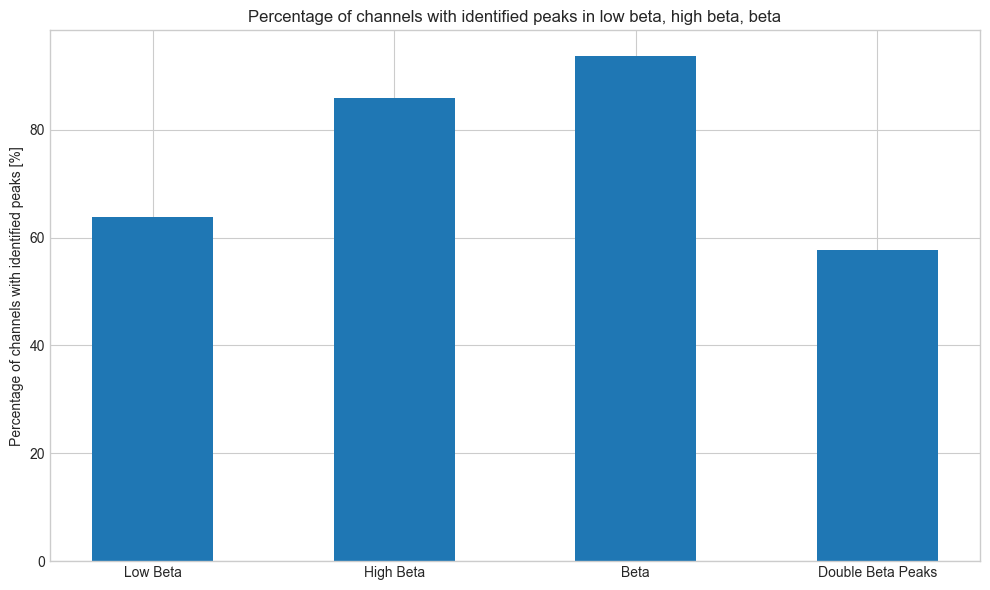

In [43]:
bar_plot = bar_plot_number_of_peaks(dataset="bipolar_beta", cohort="all_included", channel_group="all", session="all")

low beta: 41 
high beta: 54 
beta: 54 
double beta peaks: 41
total channels: 54 
low beta percentage: 75.92592592592592 
high beta percentage: 100.0 
beta percentage: 100.0 
double beta peaks percentage: 75.92592592592592


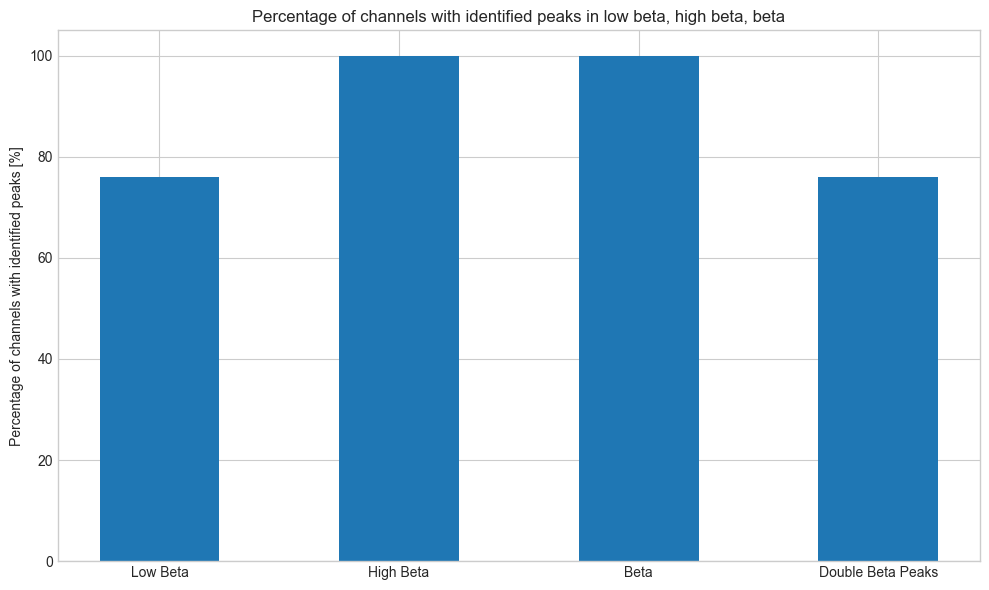

In [44]:
bar_plot = bar_plot_number_of_peaks(dataset="bipolar_highest_beta", cohort="all_included", channel_group="ring", session="fu3m")

### BIPOLAR

In [23]:
# FOOOF data only of one longterm session
# 12 LFP channels per STN

selected_fooof_data = loadResults.select_fooof_data(data="bipolar_beta",cohort="all_included")

# beta_rank_DF = loadResults.load_fooof_beta_ranks(
#         fooof_spectrum="periodic_spectrum",
#         fooof_version="v2",
#         all_or_one_chan="beta_ranks_all",
#         all_or_one_longterm_ses="one_longterm_session",
#     )

selected_fooof_data["fooof_data"]

,index,subject_hemisphere,session,bipolar_channel,fooof_error,fooof_r_sq,fooof_exponent,fooof_offset,fooof_power_spectrum,periodic_plus_aperiodic_power_log,fooof_periodic_flat,fooof_number_peaks,alpha_peak_CF_power_bandWidth,low_beta_peak_CF_power_bandWidth,high_beta_peak_CF_power_bandWidth,beta_peak_CF_power_bandWidth,gamma_peak_CF_power_bandWidth,beta_average,beta_rank
0,3,017_Right,fu3m,12,0.07857,0.972904,1.343522,0.757904,"[0.0003292927862230677, 0.0003079802974601531,...","[0.35352735458664525, 0.11698373243642358, -0....","[6.336812502902425e-05, 0.00010218204803303865...",4,"[nan, nan, nan]","[nan, nan, nan]","[29.43438184459086, 1.099716477148555, 4.71406...","[29.43438184459086, 1.099716477148555, 4.71406...","[nan, nan, nan]",0.204537,1.0
1,4,017_Right,fu3m,01,0.071117,0.979469,1.587926,1.157176,"[0.0260612717972748, 0.08068602780119916, 0.20...","[0.6815260508032184, 0.4132884933120965, 0.253...","[0.0023628423792285266, 0.01374512167041695, 0...",4,"[nan, nan, nan]","[nan, nan, nan]","[33.50000000000001, 0.34359567811682745, 3.000...","[33.50000000000001, 0.34359567811682745, 3.000...","[64.15854737876835, 0.19383025351969008, 10.73...",0.030401,3.0
2,5,017_Right,fu3m,23,0.075302,0.975031,1.291468,0.634505,"[3.658637837133938e-10, 8.781297688997824e-09,...","[0.24573455686045234, 0.018318407410551848, -0...","[9.023380458332988e-11, 3.6561550966272852e-09...",3,"[nan, nan, nan]","[13.602286189596768, 0.49020364390555904, 3.46...","[30.219295965656492, 1.0778976327745415, 6.289...","[30.219295965656492, 1.0778976327745415, 6.289...","[nan, nan, nan]",0.193264,2.0
0,12,017_Right,fu3m,1A2A,0.086413,0.969713,1.477671,1.203942,"[1.051259040174557e-05, 9.481947880196628e-06,...","[0.7591189582797522, 0.4989144774934115, 0.314...","[7.950153134128949e-07, 1.3054734695782597e-06...",3,"[nan, nan, nan]","[nan, nan, nan]","[30.823647968559502, 1.0136923869600145, 7.425...","[30.823647968559502, 1.0136923869600145, 7.425...","[nan, nan, nan]",0.277904,1.0
1,13,017_Right,fu3m,1B2B,0.074097,0.965587,1.172131,0.590142,"[0.008637710295463563, 0.008756105291477745, 0...","[0.23946149626184762, 0.034419922498690476, -0...","[0.0021667278346138965, 0.0035272626669674077,...",4,"[nan, nan, nan]","[17.35611052694957, 0.1139847371212338, 11.042...","[31.41707924195963, 0.9693953353238327, 4.1148...","[31.41707924195963, 0.9693953353238327, 4.1148...","[nan, nan, nan]",0.158807,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1,3502,084_Left,fu12m,1B1C,0.076788,0.983401,0.978101,0.245335,"[0.0005038499465231938, 0.0007384123248374008,...","[-0.04885760381391911, -0.22080402167686491, -...","[0.000244943318747232, 0.0005335240541929679, ...",4,"[9.9981622799823, 0.6762664664785228, 3.000000...","[16.353978561788214, 1.5158048943762776, 5.226...","[24.09033216572259, 1.2716368197309043, 10.686...","[16.353978561788214, 1.5158048943762776, 5.226...","[nan, nan, nan]",1.295708,1.0
2,3503,084_Left,fu12m,1A1C,0.075504,0.983576,1.178428,0.638322,"[0.0009981661203033454, 0.0017598972366603682,...","[0.2838050708190323, 0.07670967901597432, -0.0...","[0.00022557701688725285, 0.0006410360006592991...",4,"[9.660647498061278, 0.7113154679018833, 3.1398...","[17.133436855226847, 1.3989417688768562, 7.049...","[25.31888602833084, 1.0767303332301146, 6.7599...","[17.133436855226847, 1.3989417688768562, 7.049...","[nan, nan, nan]",1.197693,3.0
3,3504,084_Left,fu12m,2A2B,0.060017,0.98625,1.317129,0.846202,"[1.1151066719783387e-05, 0.0001408116205658949...","[0.44970804458186486, 0.2178085365765646, 0.05...","[1.7194657944788796e-06, 3.703674314544845e-05...",4,"[9.411092043077709, 0.33303177512364096, 3.000...","[17.24255752229247, 1.046541254272136, 4.81635...","[22.557323777656077, 0.8134137635139544, 3.000...","[17.24255752229247, 1.046541254272136, 4.81635...","[nan, nan, nan]",0.463299,4.0
4,3505,084_Left,fu12m,2B2C,0.074114,0.97023,0.964667,0.46308,"[0.004093678962242331, 0.0063080130345265495, ...","[0.17387975

In [25]:
# FOOOF data only of one longterm session
# only highest beta channel (rank 1) per LFP group

selected_fooof_data = loadResults.select_fooof_data(data="bipolar_highest_beta",cohort="all_included")

# beta_rank_DF = loadResults.load_fooof_beta_ranks(
#         fooof_spectrum="periodic_spectrum",
#         fooof_version="v2",
#         all_or_one_chan="highest_beta",
#         all_or_one_longterm_ses="one_longterm_session",
#     )

selected_fooof_data["fooof_data"].head()

,index,subject_hemisphere,session,bipolar_channel,fooof_error,fooof_r_sq,fooof_exponent,fooof_offset,fooof_power_spectrum,periodic_plus_aperiodic_power_log,fooof_periodic_flat,fooof_number_peaks,alpha_peak_CF_power_bandWidth,low_beta_peak_CF_power_bandWidth,high_beta_peak_CF_power_bandWidth,beta_peak_CF_power_bandWidth,gamma_peak_CF_power_bandWidth,beta_average,beta_rank
0,3,017_Right,fu3m,12,0.07857,0.972904,1.343522,0.757904,"[0.0003292927862230677, 0.0003079802974601531,...","[0.35352735458664525, 0.11698373243642358, -0....","[6.336812502902425e-05, 0.00010218204803303865...",4,"[nan, nan, nan]","[nan, nan, nan]","[29.43438184459086, 1.099716477148555, 4.71406...","[29.43438184459086, 1.099716477148555, 4.71406...","[nan, nan, nan]",0.204537,1.0
0,12,017_Right,fu3m,1A2A,0.086413,0.969713,1.477671,1.203942,"[1.051259040174557e-05, 9.481947880196628e-06,...","[0.7591189582797522, 0.4989144774934115, 0.314...","[7.950153134128949e-07, 1.3054734695782597e-06...",3,"[nan, nan, nan]","[nan, nan, nan]","[30.823647968559502, 1.0136923869600145, 7.425...","[30.823647968559502, 1.0136923869600145, 7.425...","[nan, nan, nan]",0.277904,1.0
5,11,017_Right,fu3m,2A2C,0.070059,0.975923,1.279358,0.622745,"[1.3979065716096528e-06, 2.5015002960149246e-0...","[0.2376206914896252, 0.01233768192489373, -0.1...","[3.512707128119114e-07, 1.0559606045368374e-06...",4,"[nan, nan, nan]","[13.59303036339205, 0.12463061825765231, 3.000...","[28.344306091350532, 0.9307513411542273, 9.686...","[28.344306091350532, 0.9307513411542273, 9.686...","[nan, nan, nan]",0.172262,1.0
2,20,017_Right,fu12m,23,0.064378,0.989523,1.700796,1.440666,"[2.6991400101650243e-05, 5.4799935694127555e-0...","[0.9286766131841131, 0.6291855485581883, 0.416...","[1.3814456454305008e-06, 5.589611276521289e-06...",4,"[nan, nan, nan]","[13.805828105459103, 0.7460678514380996, 3.064...","[28.513423058870664, 0.9111804619360752, 5.374...","[28.513423058870664, 0.9111804619360752, 5.374...","[nan, nan, nan]",0.516692,1.0
0,27,017_Right,fu12m,1A2A,0.054754,0.98773,1.600978,1.328914,"[0.0011917227674977937, 0.0012032524253271504,...","[0.8470456604000512, 0.5651960382547497, 0.365...","[7.36123518097955e-05, 0.00014223816337737217,...",4,"[nan, nan, nan]","[nan, nan, nan]","[27.185455000237216, 0.41889408694839625, 12.0...","[27.185455000237216, 0.41889408694839625, 12.0...","[63.12950075977409, 0.2016035648850072, 3.0000...",0.111572,1.0


### MONOPOLAR

In [86]:
selected_fooof_data = loadResults.select_fooof_data(dataset="monopolar_beta",cohort="all_included")

# loaded_fooof_monopolar = loadResults.load_pickle_group_result(
#         filename=f"fooof_monoRef_all_contacts_weight_beta_psd_by_inverse_sq_distance_v2",
#         fooof_version="v2",
#     )

selected_fooof_data["fooof_data"].loc[selected_fooof_data["fooof_data"]["subject_hemisphere"] == "017_Right"]

,index,coord_z,coord_xy,session,subject_hemisphere,estimated_monopolar_beta_psd,contact,beta_relative_to_max,beta_cluster,rank_8,beta_psd_rel_to_rank1,beta_psd_rel_range_0_to_1,subject
24,416,2.0+0.0j,0.650000+0.000000j,fu3m,017_Right,0.865548,1A,0.599964,2,4.0,0.599964,0.542814,017
25,417,2.0+0.0j,-0.325000+0.562917j,fu3m,017_Right,0.802782,1B,0.556457,2,6.0,0.556457,0.493091,017
26,418,2.0+0.0j,-0.325000-0.562917j,fu3m,017_Right,0.844396,1C,0.585302,2,5.0,0.585302,0.526057,017
27,419,4.0+0.0j,0.650000+0.000000j,fu3m,017_Right,1.442667,2A,1.000000,1,1.0,1.000000,1.000000,017
28,420,4.0+0.0j,-0.325000+0.562917j,fu3m,017_Right,1.189430,2B,0.824466,1,3.0,0.824466,0.799389,017
29,421,4.0+0.0j,-0.325000-0.562917j,fu3m,017_Right,1.279271,2C,0.886740,1,2.0,0.886740,0.870560,017
30,752,0.0+0.0j,0.000000+0.000000j,fu3m,017_Right,0.180339,0,0.125004,3,8.0,0.125004,0.000000,017
31,753,6.0+0.0j,0.000000+0.000000j,fu3m,017_Right,0.401397,3,0.278233,3,7.0,0.278233,0.175120,017
32,864,2.0+0.0j,0.650000+0.000000j,fu12m,017_Right,0.459436,1A,0.541168,2,6.0,0.541168,0.404618,017
33,865,2.0+0.0j,-0.325000+0.562917j,fu12m,017_Right,0.353771,1B,0.416706,2,7.0,0.416706,0.243115,017


## Description of data

In [ ]:
def calculate_statistics(data):
    median = np.median(data)
    q1 = np.percentile(data, 25)  # First quartile
    q3 = np.percentile(data, 75)  # Third quartile
    stats = scipy.stats.describe(data)
    std_dev = np.std(data, ddof=1)  # Standard deviation with Bessel's correction
    return {
        "number_observations": stats.nobs,
        "min": stats.minmax[0],
        "max": stats.minmax[1],
        "mean": stats.mean,
        "std_dev": std_dev,
        "variance": stats.variance,
        "skewness": stats.skewness,
        "kurtosis": stats.kurtosis,
        "median": median,
        "q1": q1,
        "q3": q3,
    }

## Spatial distribution: Bipolar LFPs

Find original functions in Permutation_rankings.py

file:  revision_group_2_bipolar_LFPs_beta_correlations_per_stn.xlsx 
written in:  /Users/jenniferbehnke/Dropbox/work/ResearchProjects/BetaSenSightLongterm/results


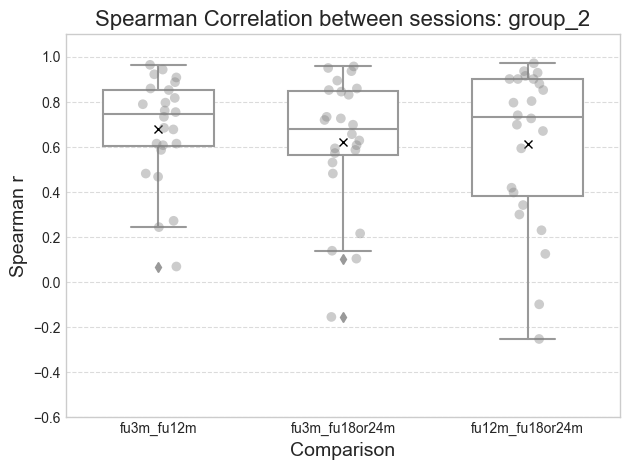

In [443]:
spearman = spatial_distribution.plot_boxplot_spearman_r_values(cohort="group_2", all_groups_together="yes")

In [444]:
spearman["significant_correlations"]

{'fu3m_fu12m': (19, 79.16666666666666),
 'fu3m_fu18or24m': (17, 70.83333333333334),
 'fu12m_fu18or24m': (16, 66.66666666666666)}

In [445]:
spearman["spearman_result_df"]

,comparison,channel_group,sample_size_stn,standard_deviation_spearman_values,mean_spearman_values,median_spearman_values,fisher_transformation_spearman_r,standard_deviation_pval,mean_pval,median_pval,session_1,session_2
fu3m_fu3m_all_LFPs,fu3m_fu3m,all_LFPs,24,0.0,1.0,1.0,"[11.859499013855018, 11.859499013855018, 11.85...",0.0,0.0,0.0,fu3m,fu3m
fu3m_fu12m_all_LFPs,fu3m_fu12m,all_LFPs,24,0.229303,0.680361,0.744755,"[0.9379212932192982, 0.07004439658534087, 1.77...",0.192302,0.08738,0.005526,fu3m,fu12m
fu3m_fu18or24m_all_LFPs,fu3m_fu18or24m,all_LFPs,24,0.284183,0.624417,0.678322,"[0.6737062867878416, 1.4470343098887455, 1.921...",0.232981,0.124447,0.01578,fu3m,fu18or24m
fu12m_fu3m_all_LFPs,fu12m_fu3m,all_LFPs,24,0.229303,0.680361,0.744755,"[0.9379212932192982, 0.07004439658534087, 1.77...",0.192302,0.08738,0.005526,fu12m,fu3m
fu12m_fu12m_all_LFPs,fu12m_fu12m,all_LFPs,24,0.0,1.0,1.0,"[11.859499013855018, 11.859499013855018, 11.85...",0.0,0.0,0.0,fu12m,fu12m
fu12m_fu18or24m_all_LFPs,fu12m_fu18or24m,all_LFPs,24,0.342074,0.612471,0.734266,"[1.110377537373207, 0.12654531384108095, 1.483...",0.227797,0.143256,0.006578,fu12m,fu18or24m
fu18or24m_fu3m_all_LFPs,fu18or24m_fu3m,all_LFPs,24,0.284183,0.624417,0.678322,"[0.6737062867878416, 1.4470343098887455, 1.921...",0.232981,0.124447,0.01578,fu18or24m,fu3m
fu18or24m_fu12m_all_LFPs,fu18or24m_fu12m,all_LFPs,24,0.342074,0.612471,0.734266,"[1.110377537373207, 0.12654531384108095, 1.483...",0.227797,0.143256,0.006578,fu18or24m,fu12m
fu18or24m_fu18or24m_all_LFPs,fu18or24m_fu18or24m,all_LFPs,24,0.0,1.0,1.0,"[11.859499013855018, 11.859499013855018, 11.85...",0.0,0.0,0.0,fu18or24m,fu18or24m


file:  revision_group_2_bipolar_LFPs_beta_correlations_per_stn.xlsx 
written in:  /Users/jenniferbehnke/Dropbox/work/ResearchProjects/BetaSenSightLongterm/results
Figures revision_t-test_fisher_transformed_Spearman_coeff_None_bipolar_group_2_all_LFPs.svg and revision_t-test_fisher_transformed_Spearman_coeff_None_bipolar_group_2_all_LFPs.png 
were written in: /Users/jenniferbehnke/Dropbox/work/ResearchProjects/BetaSenSightLongterm/figures.


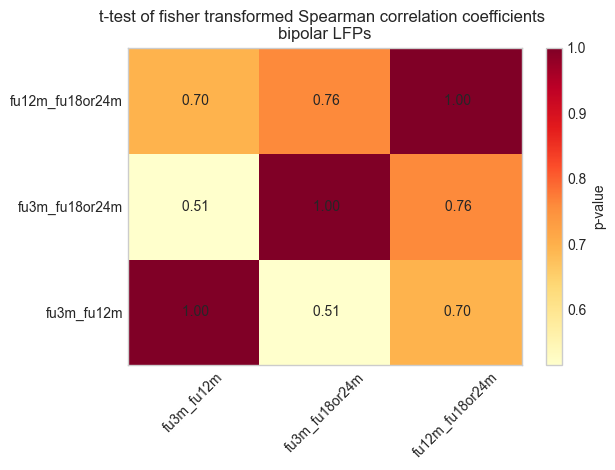

In [429]:
t_test_result = spatial_distribution.t_test_fisher_transformed_correlation_coeff(cohort="group_2", all_groups_together="yes", correction=None)

In [430]:
t_test_result["t-test_results"]

,comparison_1,comparison_2,statistic,p-value
fu3m_fu12m_vs_fu3m_fu18or24m,fu3m_fu12m,fu3m_fu18or24m,0.661599,0.514803
fu3m_fu12m_vs_fu12m_fu18or24m,fu3m_fu12m,fu12m_fu18or24m,0.395692,0.695979
fu3m_fu18or24m_vs_fu3m_fu12m,fu3m_fu18or24m,fu3m_fu12m,-0.661599,0.514803
fu3m_fu18or24m_vs_fu12m_fu18or24m,fu3m_fu18or24m,fu12m_fu18or24m,-0.308492,0.760485
fu12m_fu18or24m_vs_fu3m_fu12m,fu12m_fu18or24m,fu3m_fu12m,-0.395692,0.695979
fu12m_fu18or24m_vs_fu3m_fu18or24m,fu12m_fu18or24m,fu3m_fu18or24m,0.308492,0.760485


In [385]:
t_test_result["comparison_pairs"]

[(0, 1), (1, 0)]

In [386]:
t_test_result["all_p_values"]

[0.6959785629097512, 0.6959785629097512]

In [178]:
t_test_result["corrected_p_values"]

array([0.28321401, 0.28321401, 0.28321401, 0.26570682, 0.28321401,
       0.26570682])

In [179]:
t_test_result["comparison_matrix"]

array([[1.        , 0.28321401, 0.28321401],
       [0.28321401, 1.        , 0.26570682],
       [0.28321401, 0.26570682, 1.        ]])

## Spatial distribution: Monopolar

In [ ]:
fooof_spearman_correlation = groupMonopol.fooof_monopol_psd_spearman_betw_sessions(
    mean_or_median="mean",
    only_segmental="no",
    values_to_correlate="not_normalized",
    similarity_calculation="inverse_sq_distance",
    fooof_version="v2"
)

In [270]:
monopolar = spatial_distribution.fooof_monopol_psd_spearman_betw_sessions(
    cohort="group_3",
    mean_or_median="mean",
    only_segmental="yes",
    values_to_correlate="not_normalized",
    similarity_calculation="inverse_sq_distance",
    fooof_version="v2")

only segmental contacts included
only segmental contacts included
only segmental contacts included
only segmental contacts included
only segmental contacts included
only segmental contacts included
only segmental contacts included
only segmental contacts included
only segmental contacts included
only segmental contacts included
only segmental contacts included
only segmental contacts included
only segmental contacts included
only segmental contacts included
only segmental contacts included
only segmental contacts included
file:  revision_fooof_monopol_inverse_sq_distance_beta_correlations_per_stn_v2.xlsx 
written in:  /Users/jenniferbehnke/Dropbox/work/ResearchProjects/BetaSenSightLongterm/results


all contacts included
all contacts included
all contacts included
all contacts included
all contacts included
all contacts included
all contacts included
all contacts included
all contacts included
file:  revision_fooof_monopol_inverse_sq_distance_beta_correlations_per_stn_v2.xlsx 
written in:  /Users/jenniferbehnke/Dropbox/work/ResearchProjects/BetaSenSightLongterm/results


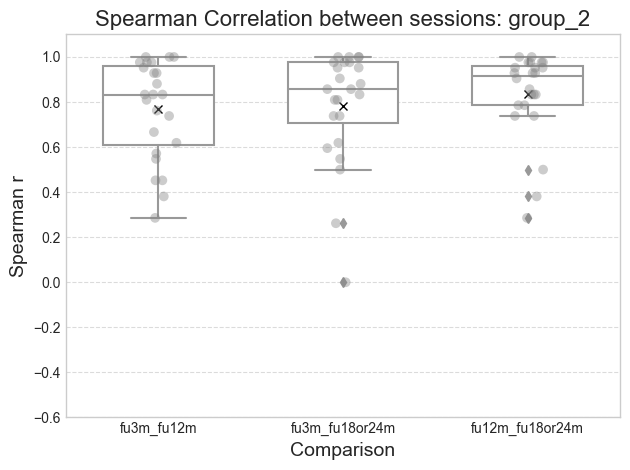

In [459]:
plot_monopolar = spatial_distribution.plot_boxplot_monopolar_spearman_r_values(cohort="group_2", only_segmental="no")

In [447]:
plot_monopolar["spearman_result_df"]

,session_1,session_2,session_comparison,mean_spearmanr,mean_pval,spearman_std,sample_size
postop_postop_spearman_m,postop,postop,postop_postop,1.0,0.0,0.0,30
postop_fu3m_spearman_m,postop,fu3m,postop_fu3m,0.744444,0.097205,0.287227,30
postop_fu12m_spearman_m,postop,fu12m,postop_fu12m,0.736508,0.117917,0.2954,30
fu3m_postop_spearman_m,fu3m,postop,fu3m_postop,0.744444,0.097205,0.287227,30
fu3m_fu3m_spearman_m,fu3m,fu3m,fu3m_fu3m,1.0,0.0,0.0,30
fu3m_fu12m_spearman_m,fu3m,fu12m,fu3m_fu12m,0.786508,0.074745,0.213799,30
fu12m_postop_spearman_m,fu12m,postop,fu12m_postop,0.736508,0.117917,0.2954,30
fu12m_fu3m_spearman_m,fu12m,fu3m,fu12m_fu3m,0.786508,0.074745,0.213799,30
fu12m_fu12m_spearman_m,fu12m,fu12m,fu12m_fu12m,1.0,0.0,0.0,30


In [448]:
plot_monopolar["single_stn_spearman_DF_copy"].head()

,session_comparison,subject_hemisphere,spearman_r,pval,significant_correlation
postop_fu3m_024_Left,postop_fu3m,024_Left,0.904762,0.002008,yes
postop_fu3m_024_Right,postop_fu3m,024_Right,0.309524,0.455645,no
postop_fu3m_025_Left,postop_fu3m,025_Left,0.97619,0.000033,yes
postop_fu3m_025_Right,postop_fu3m,025_Right,0.928571,0.000863,yes
postop_fu3m_026_Left,postop_fu3m,026_Left,0.833333,0.010176,yes


In [460]:
plot_monopolar["significant_correlations"]

{'fu3m_fu12m': (16, 66.66666666666666),
 'fu3m_fu18or24m': (18, 75.0),
 'fu12m_fu18or24m': (21, 87.5)}

all contacts included
all contacts included
all contacts included
all contacts included
all contacts included
all contacts included
all contacts included
all contacts included
all contacts included
file:  revision_fooof_monopol_inverse_sq_distance_beta_correlations_per_stn_v2.xlsx 
written in:  /Users/jenniferbehnke/Dropbox/work/ResearchProjects/BetaSenSightLongterm/results
Figures revision_t-test_fisher_transformed_Spearman_coeff_monoolar_only_segmental_no_None_group_2.svg and revision_t-test_fisher_transformed_Spearman_coeff_monoolar_only_segmental_no_None_group_2.png 
were written in: /Users/jenniferbehnke/Dropbox/work/ResearchProjects/BetaSenSightLongterm/figures.


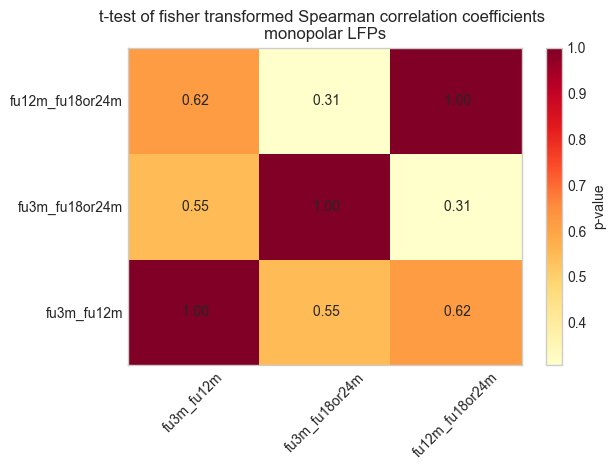

In [454]:
ttest_monopolar = spatial_distribution.t_test_fisher_transformed_spearman_monopolar(cohort="group_2", only_segmental="no", correction=None)

In [451]:
ttest_monopolar["all_p_values"]

[0.3983019300571302,
 0.11378596903112481,
 0.3983019300571302,
 0.028418179354819047,
 0.11378596903112481,
 0.028418179354819047]

In [294]:
list(ttest_monopolar["corrected_p_values"])

[0.7966038601142604,
 0.45514387612449925,
 0.7966038601142604,
 0.17050907612891428,
 0.45514387612449925,
 0.17050907612891428]

In [295]:
ttest_monopolar["comparison_pairs"]

[(0, 1), (0, 2), (1, 0), (1, 2), (2, 0), (2, 1)]

In [455]:
ttest_monopolar["spearman_group_results"]

,session_1,session_2,session_comparison,mean_spearmanr,mean_pval,spearman_std,sample_size
fu3m_fu3m_spearman_m,fu3m,fu3m,fu3m_fu3m,1.0,0.0,0.0,24
fu3m_fu12m_spearman_m,fu3m,fu12m,fu3m_fu12m,0.766865,0.081374,0.214724,24
fu3m_fu18or24m_spearman_m,fu3m,fu18or24m,fu3m_fu18or24m,0.782738,0.093828,0.248608,24
fu12m_fu3m_spearman_m,fu12m,fu3m,fu12m_fu3m,0.766865,0.081374,0.214724,24
fu12m_fu12m_spearman_m,fu12m,fu12m,fu12m_fu12m,1.0,0.0,0.0,24
fu12m_fu18or24m_spearman_m,fu12m,fu18or24m,fu12m_fu18or24m,0.834325,0.05037,0.188291,24
fu18or24m_fu3m_spearman_m,fu18or24m,fu3m,fu18or24m_fu3m,0.782738,0.093828,0.248608,24
fu18or24m_fu12m_spearman_m,fu18or24m,fu12m,fu18or24m_fu12m,0.834325,0.05037,0.188291,24
fu18or24m_fu18or24m_spearman_m,fu18or24m,fu18or24m,fu18or24m_fu18or24m,1.0,0.0,0.0,24


In [456]:
ttest_monopolar["t_test_results_df"]

,comparison_1,comparison_2,fisher_comparison_1,fisher_comparison_2,statistic,p-value
fu3m_fu12m_vs_fu3m_fu18or24m,fu3m_fu12m,fu3m_fu18or24m,"[0.40117323626246876, 0.6496414920651306, 11.8...","[11.859499013855018, 1.1256458993032479, 11.85...",-0.610005,0.547839
fu3m_fu12m_vs_fu12m_fu18or24m,fu3m_fu12m,fu12m_fu18or24m,"[0.40117323626246876, 0.6496414920651306, 11.8...","[0.40117323626246876, 1.6479184330021657, 11.8...",0.502392,0.620168
fu3m_fu18or24m_vs_fu3m_fu12m,fu3m_fu18or24m,fu3m_fu12m,"[11.859499013855018, 1.1256458993032479, 11.85...","[0.40117323626246876, 0.6496414920651306, 11.8...",0.610005,0.547839
fu3m_fu18or24m_vs_fu12m_fu18or24m,fu3m_fu18or24m,fu12m_fu18or24m,"[11.859499013855018, 1.1256458993032479, 11.85...","[0.40117323626246876, 1.6479184330021657, 11.8...",1.044538,0.307091
fu12m_fu18or24m_vs_fu3m_fu12m,fu12m_fu18or24m,fu3m_fu12m,"[0.40117323626246876, 1.6479184330021657, 11.8...","[0.40117323626246876, 0.6496414920651306, 11.8...",-0.502392,0.620168
fu12m_fu18or24m_vs_fu3m_fu18or24m,fu12m_fu18or24m,fu3m_fu18or24m,"[0.40117323626246876, 1.6479184330021657, 11.8...","[11.859499013855018, 1.1256458993032479, 11.85...",-1.044538,0.307091


## Maximal beta contact positional stability

In [461]:
# write changes of beta ranks 
changes = spatial_distribution.write_df_xy_changes_of_beta_ranks(cohort="all_included", ranks_included=[1, 2])

In [462]:
changes["sample_size_dataframe"]

,session_comparison,sample_size,percentage_stable_level,percentage_stable_direction
0_0_beta_rank_1,0_0,52,1.0,1.0
0_3_beta_rank_1,0_3,40,0.7,0.675
0_12_beta_rank_1,0_12,42,0.738095,0.619048
0_18_beta_rank_1,0_18,22,0.590909,0.681818
3_0_beta_rank_1,3_0,40,0.7,0.675
3_3_beta_rank_1,3_3,54,1.0,1.0
3_12_beta_rank_1,3_12,44,0.795455,0.636364
3_18_beta_rank_1,3_18,26,0.846154,0.730769
12_0_beta_rank_1,12_0,42,0.738095,0.619048
12_3_beta_rank_1,12_3,44,0.795455,0.636364


In [463]:
changes["sample_size_dataframe_rank_2"]

,session_comparison,sample_size,percentage_stable_level,percentage_stable_direction
0_0_beta_rank_2,0_0,52,1.0,1.0
0_3_beta_rank_2,0_3,40,0.6,0.425
0_12_beta_rank_2,0_12,42,0.690476,0.357143
0_18_beta_rank_2,0_18,22,0.545455,0.318182
3_0_beta_rank_2,3_0,40,0.6,0.425
3_3_beta_rank_2,3_3,54,1.0,1.0
3_12_beta_rank_2,3_12,44,0.772727,0.409091
3_18_beta_rank_2,3_18,26,0.769231,0.461538
12_0_beta_rank_2,12_0,42,0.690476,0.357143
12_3_beta_rank_2,12_3,44,0.772727,0.409091


In [366]:
changes["coord_difference_dataframe"].head()

,session_comparison,session_1,session_2,subject_hemisphere,beta_rank,contact_session_1,contact_session_2,x_difference,y_difference
0_0_024_Right_1,0_0,0,0,024_Right,1,1A,1A,0,0
0_0_024_Right_2,0_0,0,0,024_Right,2,1B,1B,0,0
0_0_024_Left_1,0_0,0,0,024_Left,1,1A,1A,0,0
0_0_024_Left_2,0_0,0,0,024_Left,2,1C,1C,0,0
0_0_025_Right_1,0_0,0,0,025_Right,1,1A,1A,0,0


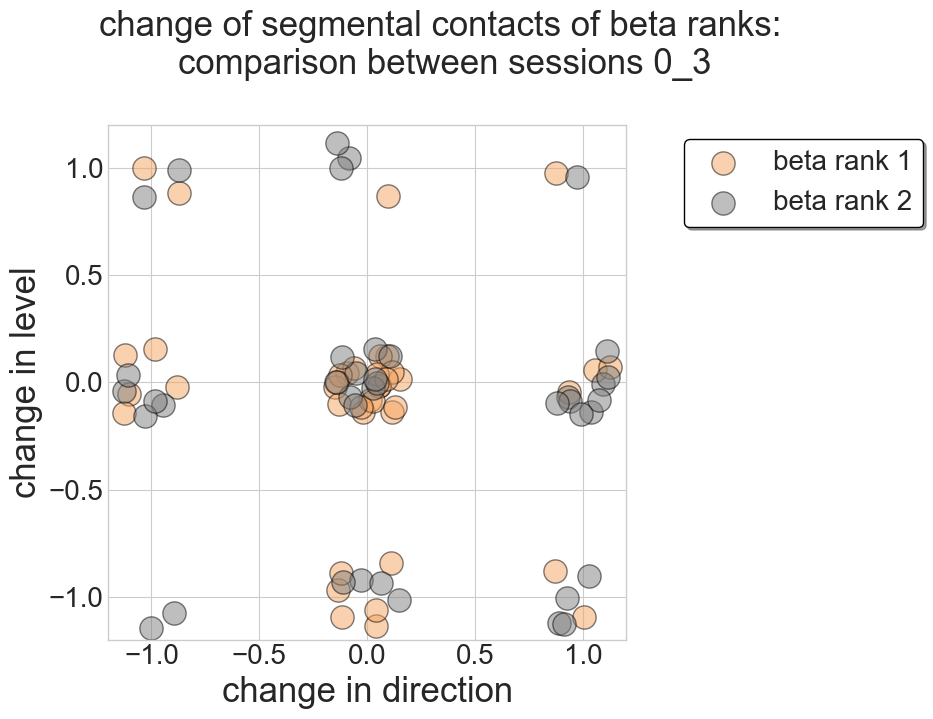

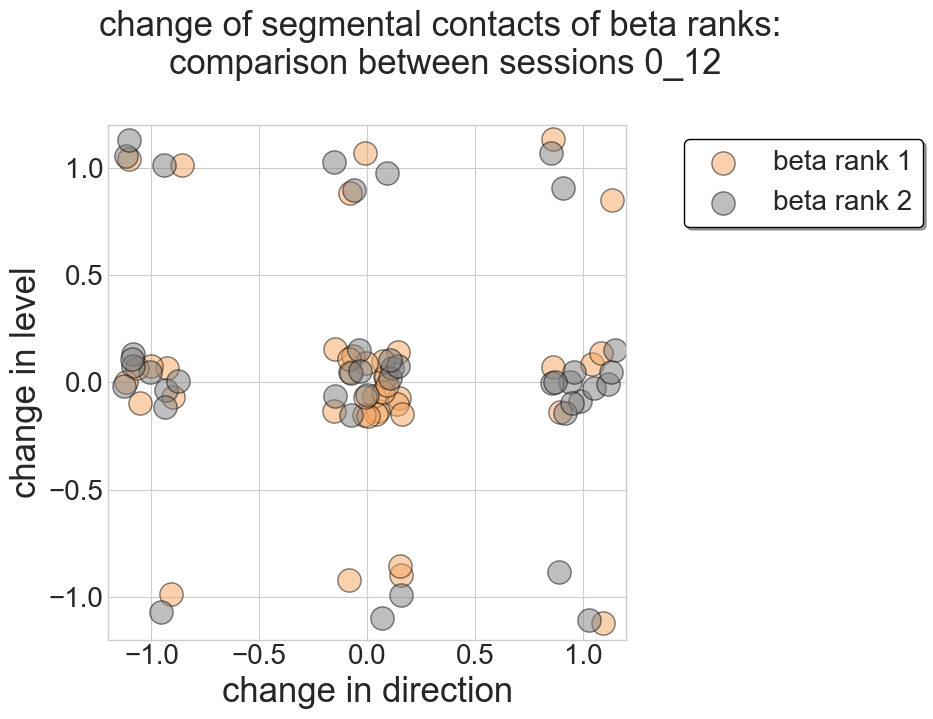

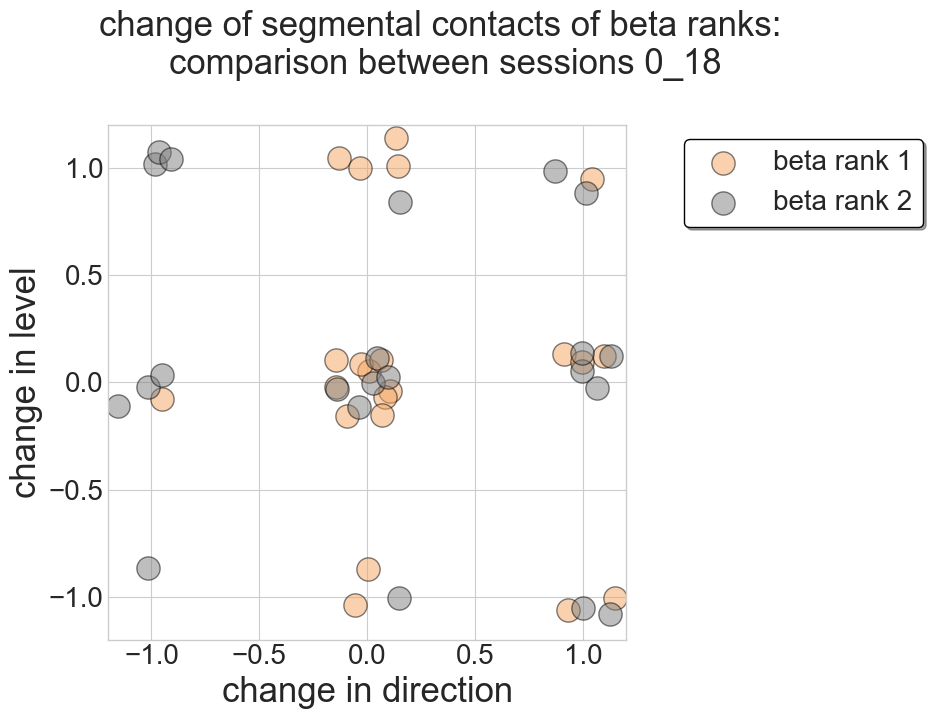

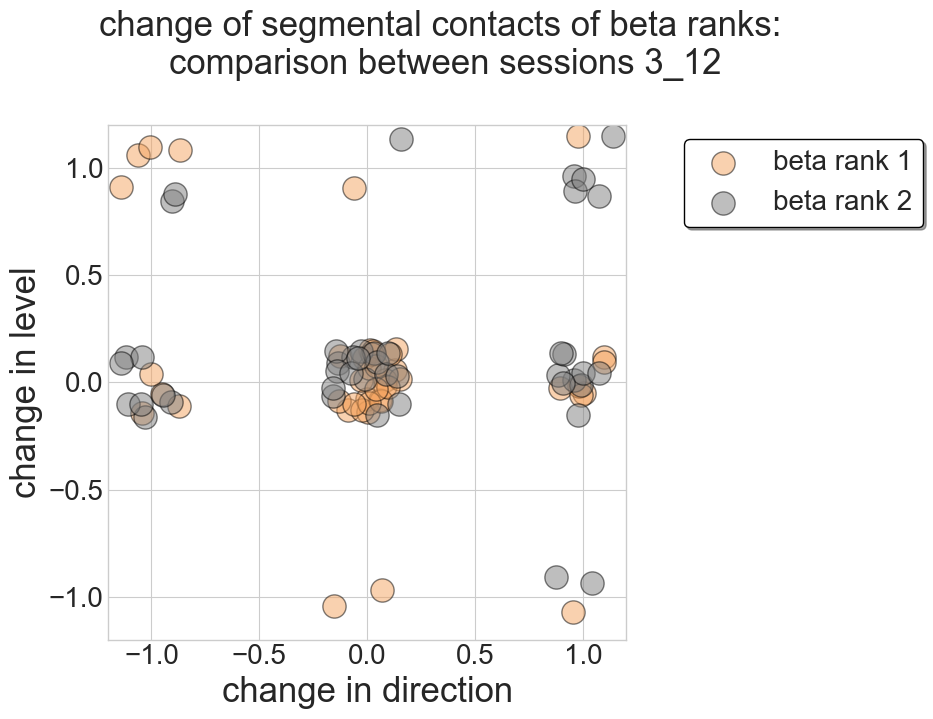

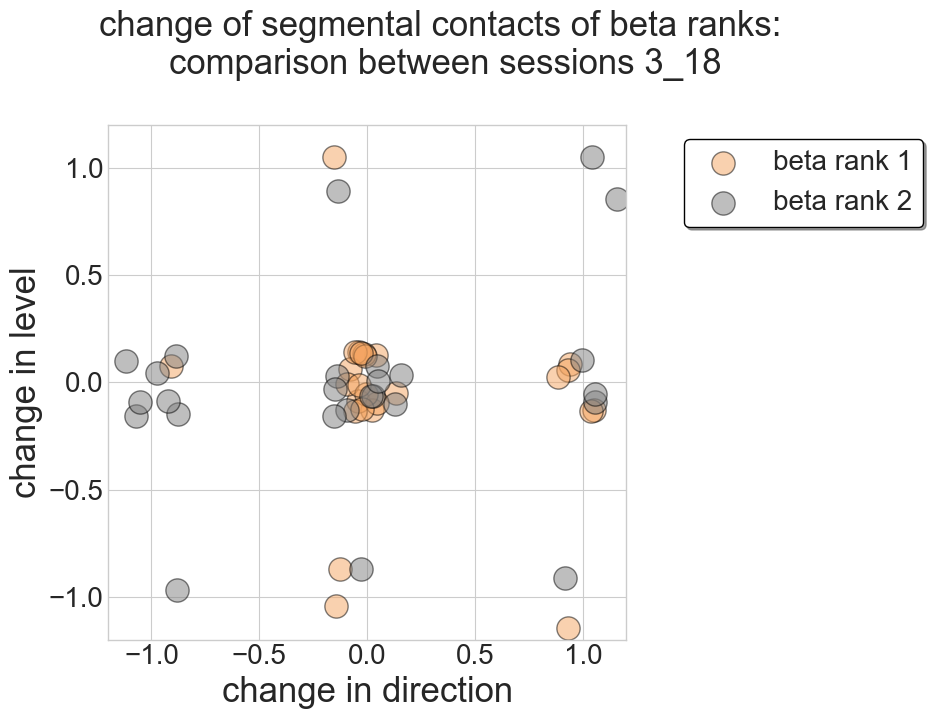

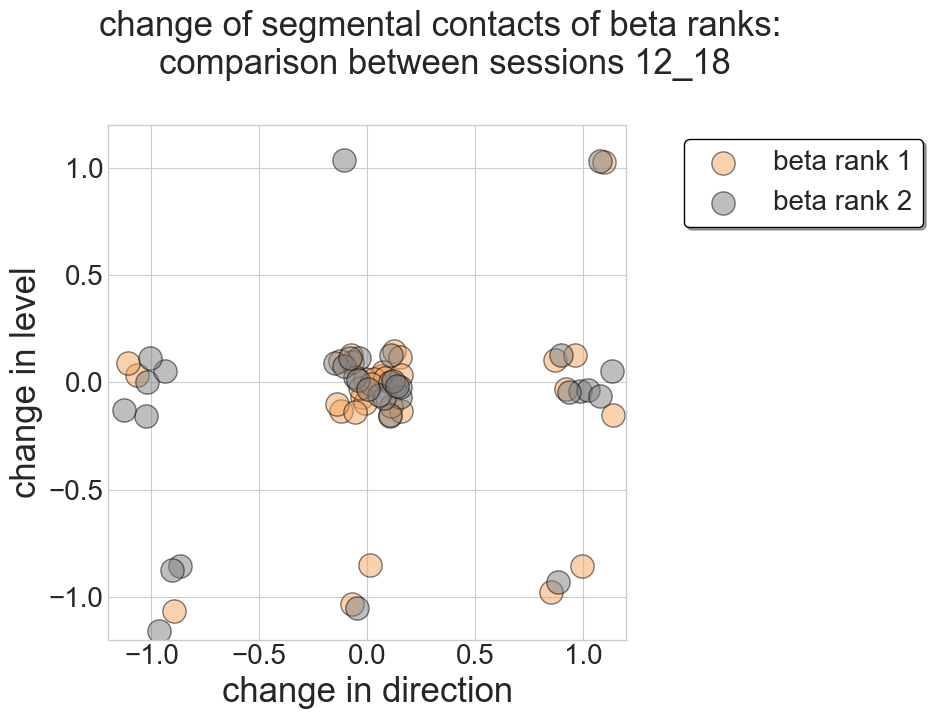

In [374]:
plot_changes = spatial_distribution.fooof_beta_rank_coord_difference_scatterplot(cohort="all_included", ranks_included=[1, 2])

## Active vs Inactive contacts

In [6]:
fooof_mono_beta_active_vs_inactive = activeStimContacts.fooof_mono_beta_and_clinical_activity_write_dataframes(
    fooof_version="v2", cohort="all_included"
)
fooof_mono_beta_active_vs_inactive["single_contacts"].head()

Excel file loaded:  BestClinicalStimulation.xlsx 
loaded from:  /Users/jenniferbehnke/Dropbox/work/ResearchProjects/BetaSenSightLongterm/data


,coord_z,coord_xy,session,subject_hemisphere,estimated_monopolar_beta_psd,contact,beta_relative_to_max,beta_cluster,rank_8,beta_psd_rel_to_rank1,beta_psd_rel_range_0_to_1,subject,current_polarity,clinical_activity,session_clinical_activity
0,2.0+0.0j,0.650000+0.000000j,fu3m,017_Right,0.865548,1A,0.599964,2,4.0,0.599964,0.542814,017,100.0,active,fu3m_active
1,2.0+0.0j,-0.325000+0.562917j,fu3m,017_Right,0.802782,1B,0.556457,2,6.0,0.556457,0.493091,017,0.0,inactive,fu3m_inactive
2,2.0+0.0j,-0.325000-0.562917j,fu3m,017_Right,0.844396,1C,0.585302,2,5.0,0.585302,0.526057,017,0.0,inactive,fu3m_inactive
3,4.0+0.0j,0.650000+0.000000j,fu3m,017_Right,1.442667,2A,1.000000,1,1.0,1.000000,1.000000,017,0.0,inactive,fu3m_inactive
4,4.0+0.0j,-0.325000+0.562917j,fu3m,017_Right,1.189430,2B,0.824466,1,3.0,0.824466,0.799389,017,0.0,inactive,fu3m_inactive


In [18]:
###### How many hemispheres have beta rank 1 or 2 or 3 active? ######

sample_size_dict = {"fu3m": 51, "fu12m": 54, "fu18or24m": 33}
results_dict = {}

fooof_mono_beta_active_vs_inactive = activeStimContacts.fooof_mono_beta_and_clinical_activity_write_dataframes(
    fooof_version="v2", cohort="all_included")

single_contacts_DF = fooof_mono_beta_active_vs_inactive["single_contacts"]

for ses in sample_size_dict.keys():

    # filter by session
    single_contacts_ses = single_contacts_DF[single_contacts_DF["session"] == ses]

    # Filter the dataframe for rows where rank is 1 or 2 and activity is "active"
    filtered_df = single_contacts_ses[(single_contacts_ses["rank_8"].isin([1.0, 2.0])) & (single_contacts_ses["clinical_activity"] == "active")]

    # Count the number of unique subjects in the filtered dataframe
    unique_subject_count = filtered_df["subject_hemisphere"].nunique()

    # Calculate the percentage of unique subjects with rank 1 or 2 marked as 'active'
    percentage = (unique_subject_count / sample_size_dict[ses]) * 100
    
    results_dict[ses] = {"total_stn": sample_size_dict[ses], 
                         "count_stn_rank1or2_active": unique_subject_count, 
                         "percentage_stn_rank1or2_active": percentage}

results_dict



Excel file loaded:  BestClinicalStimulation.xlsx 
loaded from:  /Users/jenniferbehnke/Dropbox/work/ResearchProjects/BetaSenSightLongterm/data


{'fu3m': {'total_stn': 51,
  'count_stn_rank1or2_active': 30,
  'percentage_stn_rank1or2_active': 58.82352941176471},
 'fu12m': {'total_stn': 54,
  'count_stn_rank1or2_active': 37,
  'percentage_stn_rank1or2_active': 68.51851851851852},
 'fu18or24m': {'total_stn': 33,
  'count_stn_rank1or2_active': 23,
  'percentage_stn_rank1or2_active': 69.6969696969697}}

In [8]:
############## describe the data for each subgroup ##############

all_groups = ["fu3m_active", "fu3m_inactive", "fu12m_active", "fu12m_inactive", "fu18or24m_active", "fu18or24m_inactive"]

group_results = {}
# concatenate all groups results together 
for group in all_groups:

    data = fooof_mono_beta_active_vs_inactive["single_contacts"].loc[fooof_mono_beta_active_vs_inactive["single_contacts"].session_clinical_activity == group]
    description = activeStimContacts.calculate_statistics(data = data["beta_psd_rel_to_rank1"])

    group_results[group] = description


In [9]:
group_results["fu3m_active"]

{'number_observations': 138,
 'min': 0.2346181511714986,
 'max': 1.0,
 'mean': 0.7590635860188876,
 'std_dev': 0.203922000512079,
 'variance': 0.04158418229284836,
 'skewness': -0.7162148473124456,
 'kurtosis': -0.3214524620548307,
 'median': 0.7917398092027075,
 'q1': 0.6454148879238648,
 'q3': 0.921929220124936}

Excel file loaded:  BestClinicalStimulation.xlsx 
loaded from:  /Users/jenniferbehnke/Dropbox/work/ResearchProjects/BetaSenSightLongterm/data
new files:  revision_all_included_fooof_beta_clinical_activity_statistics_rel_beta_power_to_rank_1_single_contacts_inverse_sq_distance_v2.pickle 
written in in:  /Users/jenniferbehnke/Dropbox/work/ResearchProjects/BetaSenSightLongterm/results 
new figures: revision_all_included_fooof_beta_clinical_activity_rel_beta_power_to_rank_1_single_contacts_inverse_sq_distance_v2.png 
and revision_all_included_fooof_beta_clinical_activity_rel_beta_power_to_rank_1_single_contacts_inverse_sq_distance_v2.svg
written in:  /Users/jenniferbehnke/Dropbox/work/ResearchProjects/BetaSenSightLongterm/figures


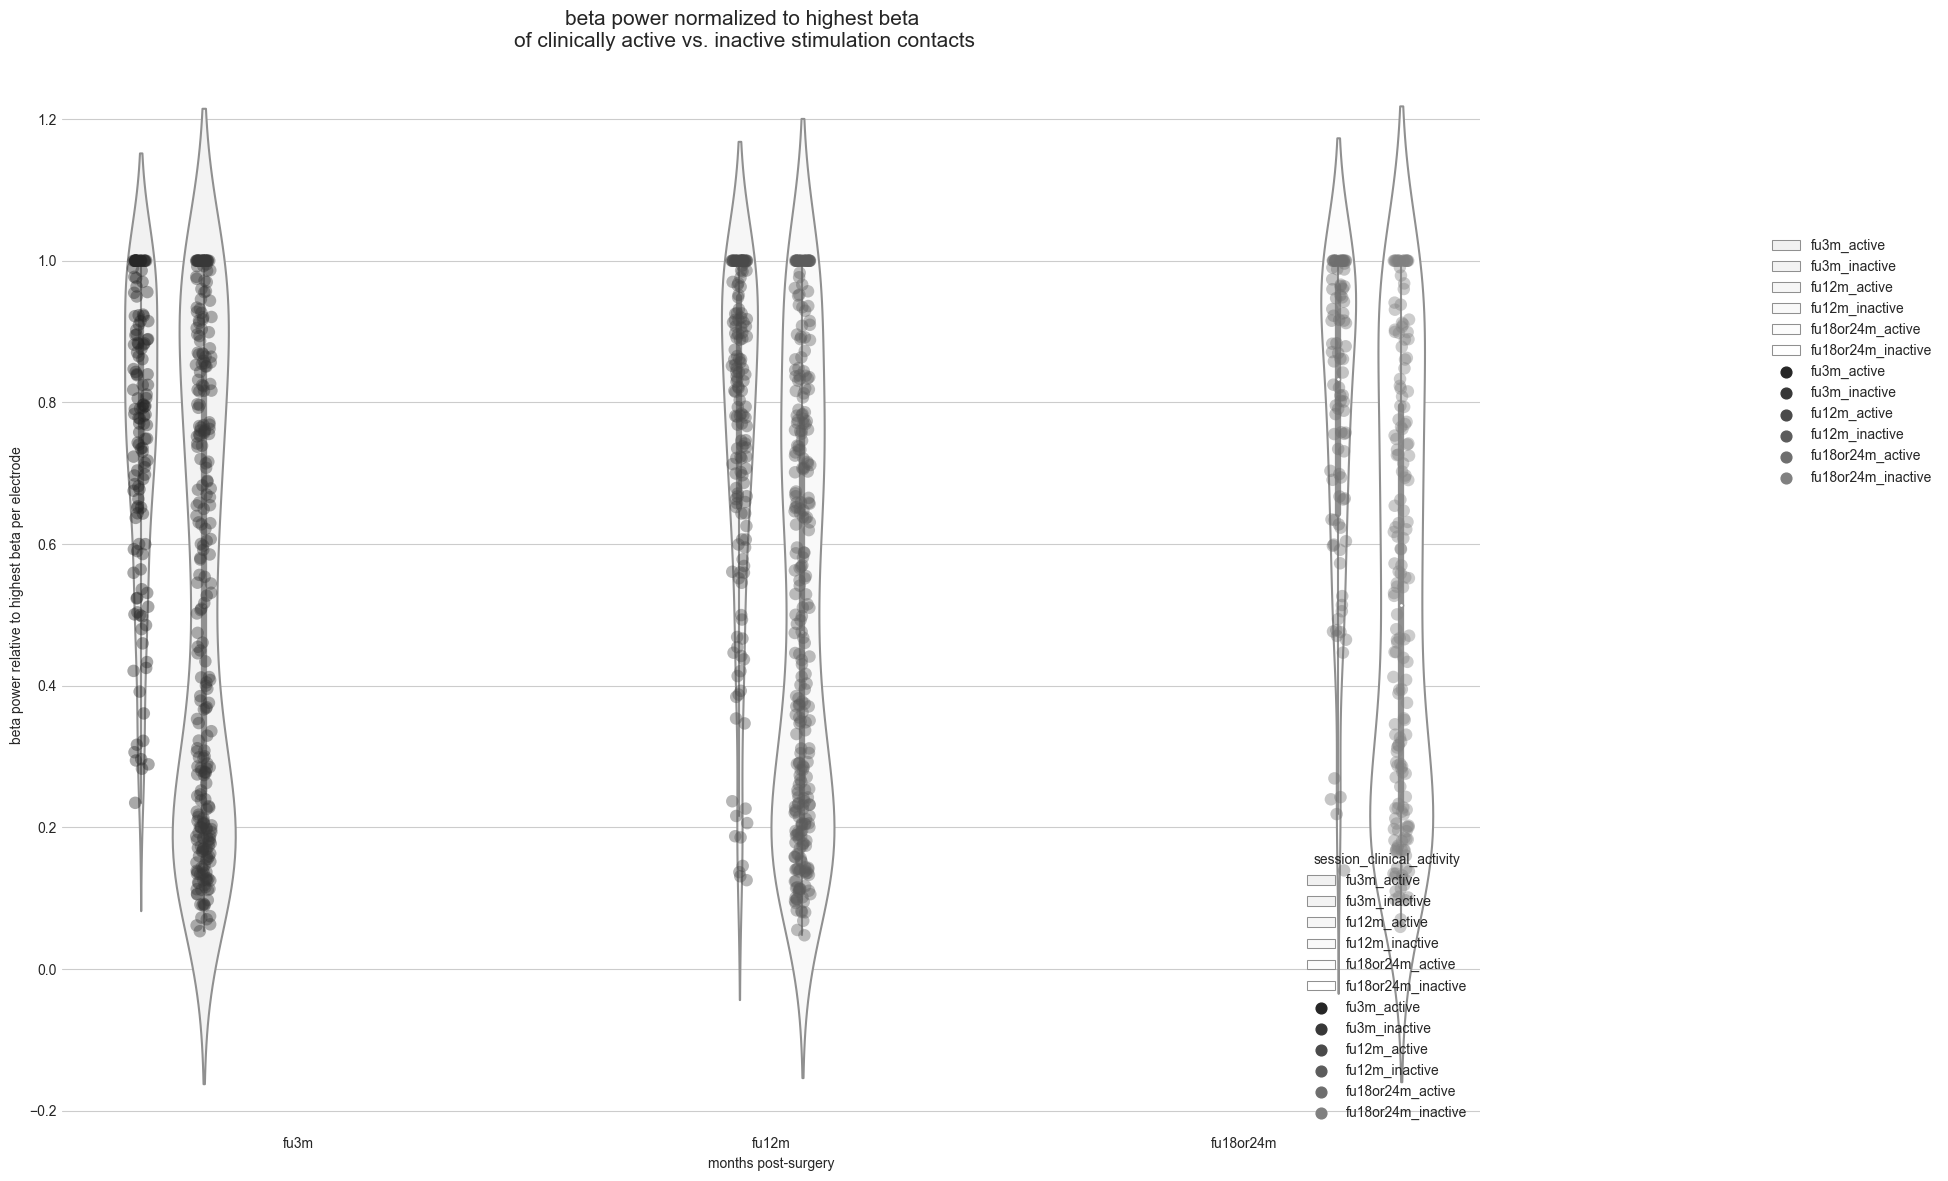

In [10]:
######### Plot violin plots of beta power relative to rank 1 for each subgroup #########

data_to_analyze = activeStimContacts.fooof_mono_beta_and_clinical_activity_statistical_test(
    single_contacts_or_average="single_contacts",
    feature="rel_beta_power_to_rank_1",
    similarity_calculation="inverse_sq_distance",
    fooof_version="v2",
    cohort="all_included"
)

In [ ]:
data_to_analyze["description_all"]
# fu3m 408 contacts -> should be 408, n=51 STN
# fu12m 432 contacts -> should be 432, n=54 STN 
# fu18m 264 contacts -> should be 264, n=33 STN

,number_observations,min_and_max,mean,variance,skewness,kurtosis,standard_deviation
fu3m_active_single_contacts_rel_beta_power_to_rank_1,138,"(0.2346181511714986, 1.0)",0.759064,0.041584,-0.716215,-0.321452,NaN
fu3m_inactive_single_contacts_rel_beta_power_to_rank_1,270,"(0.05335176059780933, 1.0)",0.526398,0.108775,0.115125,-1.569675,NaN
fu12m_active_single_contacts_rel_beta_power_to_rank_1,157,"(0.12542557669182997, 1.0)",0.758492,0.053703,-1.0464,0.365491,NaN
fu12m_inactive_single_contacts_rel_beta_power_to_rank_1,275,"(0.04761157561912571, 1.0)",0.507042,0.095485,0.197553,-1.398415,NaN
fu18or24m_active_single_contacts_rel_beta_power_to_rank_1,94,"(0.1392167948068761, 1.0)",0.782285,0.046373,-1.006104,0.342675,NaN
fu18or24m_inactive_single_contacts_rel_beta_power_to_rank_1,170,"(0.05948769175051159, 1.0)",0.524495,0.093243,0.163644,-1.394515,NaN
fu3m_active_single_contacts_rel_beta_power_to_rank_1,NaN,NaN,NaN,NaN,NaN,NaN,0.203182
fu3m_inactive_single_contacts_rel_beta_power_to_rank_1,NaN,NaN,NaN,NaN,NaN,NaN,0.329199
fu12m_active_single_contacts_rel_beta_power_to_rank_1,NaN,NaN,NaN,NaN,NaN,NaN,0.231000
fu12m_inactive_single_contacts_rel_beta_power_to_rank_1,NaN,NaN,NaN,NaN,NaN,NaN,0.308444


In [13]:
data_to_analyze["results_dictionary"]["significance_results"]

,U-val,alternative,p-val,RBC,CLES,comparison_single_contacts_rel_beta_power_to_rank_1,sample_size_one_session_activity_group
MWU,25986.0,two-sided,6.426170e-11,-0.394847,0.697424,fu3m_active_fu3m_inactive,138
MWU,31475.0,two-sided,2.208849e-15,-0.458020,0.729010,fu12m_active_fu12m_inactive,157
MWU,11811.0,two-sided,1.213814e-10,-0.478223,0.739111,fu18or24m_active_fu18or24m_inactive,94


In [14]:
data = data_to_analyze["results_dictionary"]["significance_results"]
pval = data["p-val"].values

# write each pval as float with 12 decimals
pval = [f'{x:.12f}' for x in pval]
pval

['0.000000000064', '0.000000000000', '0.000000000121']

Check if every STN has exactly 8 contacts 

In [15]:
dataframe = data_to_analyze["data_to_analyze"].loc[data_to_analyze["data_to_analyze"].session == "fu12m"] # one session only

# Define the expected values for the "contact" column
expected_contacts = ["0", "3", "1A", "1B", "1C", "2A", "2B", "2C"]

# Iterate through each subject group
for subject, group in dataframe.groupby("subject_hemisphere"):
    # Get the unique contact values for this subject
    contacts_present = set(group["contact"].astype(str))  # Ensure comparison is done as strings
    
    # Check if all expected contacts are present
    missing_contacts = set(expected_contacts) - contacts_present
    
    if missing_contacts:
        print(f"Subject {subject} is missing the following contacts: {missing_contacts}")

# fu3m: sub-030 is missing contact 2C

In [21]:
dataframe = data_to_analyze["data_to_analyze"].loc[data_to_analyze["data_to_analyze"].session == "fu18or24m"] # one session only

sub_list = dataframe.subject_hemisphere.unique()

print(len(sub_list), 8*len(sub_list), sub_list)

33 264 ['017_Right' '017_Left' '019_Right' '019_Left' '021_Right' '021_Left'
 '024_Right' '024_Left' '026_Right' '026_Left' '028_Right' '028_Left'
 '029_Right' '029_Left' '030_Right' '030_Left' '033_Right' '033_Left'
 '040_Right' '040_Left' '041_Right' '041_Left' '047_Right' '047_Left'
 '048_Right' '048_Left' '050_Right' '050_Left' '055_Right' '055_Left'
 '059_Right' '059_Left' '060_Right']


## Peak Freqeuncy analysis

In [246]:
# for pea CF analysis make sure to use around_cf_at_each_session

beta_data = peak_analysis.calculate_auc_beta_power(
        fooof_spectrum="periodic_spectrum",
        highest_beta_session="highest_fu3m",
        around_cf="around_cf_at_each_session",
        cohort="group_0"
    )


The center frequency of the beta peak was taken from each session independently to calculate AUC.
The center frequency of the beta peak was taken from each session independently to calculate AUC.
The center frequency of the beta peak was taken from each session independently to calculate AUC.
The center frequency of the beta peak was taken from each session independently to calculate AUC.
The center frequency of the beta peak was taken from each session independently to calculate AUC.
The center frequency of the beta peak was taken from each session independently to calculate AUC.
The center frequency of the beta peak was taken from each session independently to calculate AUC.
The center frequency of the beta peak was taken from each session independently to calculate AUC.
The center frequency of the beta peak was taken from each session independently to calculate AUC.
The center frequency of the beta peak was taken from each session independently to calculate AUC.
The center frequency

In [247]:
ring_data = beta_data["group_dict"]["ring"]
ring_data.keys()

Index(['subject_hemisphere', 'session', 'bipolar_channel', 'fooof_error',
       'fooof_r_sq', 'fooof_exponent', 'fooof_offset', 'fooof_power_spectrum',
       'periodic_plus_aperiodic_power_log', 'fooof_periodic_flat',
       'fooof_number_peaks', 'low_beta_peak_CF_power_bandWidth',
       'high_beta_peak_CF_power_bandWidth', 'beta_peak_CF_power_bandWidth',
       'beta_average', 'beta_rank', 'subject', 'group',
       'beta_center_frequency', 'beta_peak_power', 'beta_band_width',
       'low_beta_center_frequency', 'low_beta_peak_power',
       'low_beta_band_width', 'high_beta_center_frequency',
       'high_beta_peak_power', 'high_beta_band_width', 'round_beta_cf',
       'beta_power_auc', 'round_high_beta_cf', 'high_beta_power_auc',
       'round_low_beta_cf', 'low_beta_power_auc'],
      dtype='object')

### NO PEAKS

In [381]:
######## CHECK WHICH STNS DONT HAVE A PEAK IN BETA, LOW BETA OR HIGH BETA ########
no_peak_stn = peak_analysis.peak_overview_table(
    fooof_spectrum="periodic_spectrum",
        highest_beta_session="highest_fu3m",
        around_cf="around_cf_at_fixed_session",
        cohort="group_1")

The center frequency of session 3 was taken for every session to calculate AUC
no low beta peak
no low beta peak
no low beta peak
The center frequency of session 3 was taken for every session to calculate AUC
The center frequency of session 3 was taken for every session to calculate AUC
The center frequency of session 3 was taken for every session to calculate AUC
The center frequency of session 3 was taken for every session to calculate AUC
no low beta peak
no low beta peak
no low beta peak
The center frequency of session 3 was taken for every session to calculate AUC
no low beta peak
no low beta peak
no low beta peak
The center frequency of session 3 was taken for every session to calculate AUC
The center frequency of session 3 was taken for every session to calculate AUC
The center frequency of session 3 was taken for every session to calculate AUC
The center frequency of session 3 was taken for every session to calculate AUC
The center frequency of session 3 was taken for every ses

In [385]:
no_peak_stn["beta"]

,subject_hemisphere,session,bipolar_channel,beta_center_frequency
1,026_Left,12,01,NaN
0,061_Right,0,12,NaN
0,062_Right,12,12,NaN
2,063_Left,0,23,NaN
1,066_Right,0,01,NaN


In [389]:
no_peak_stn["low_beta"]

,subject_hemisphere,session,bipolar_channel,low_beta_center_frequency
1,024_Right,0,01,NaN
1,024_Right,3,01,NaN
1,024_Right,12,01,NaN
0,026_Right,3,12,NaN
1,026_Left,3,01,NaN
1,026_Left,12,01,NaN
0,029_Right,0,12,NaN
0,029_Right,12,12,NaN
1,029_Left,0,01,NaN
1,029_Left,12,01,NaN


In [391]:
no_peak_stn["high_beta"]

,subject_hemisphere,session,bipolar_channel,high_beta_center_frequency
0,025_Left,0,12,NaN
0,026_Right,0,12,NaN
1,026_Left,0,01,NaN
1,026_Left,12,01,NaN
0,061_Right,0,12,NaN
0,062_Right,12,12,NaN
2,063_Left,0,23,NaN
2,063_Left,12,23,NaN
1,066_Right,0,01,NaN
0,066_Left,0,12,NaN


In [69]:
total_data = beta_data["group_dict"]["ring"]
fu3m_data = total_data.loc[total_data["session"] == 3]
fu3m_data.loc[fu3m_data["subject_hemisphere"] == "024_Right"]

,subject_hemisphere,session,bipolar_channel,fooof_error,fooof_r_sq,fooof_exponent,fooof_offset,fooof_power_spectrum,periodic_plus_aperiodic_power_log,fooof_periodic_flat,...,low_beta_band_width,high_beta_center_frequency,high_beta_peak_power,high_beta_band_width,round_beta_cf,beta_power_auc,round_high_beta_cf,high_beta_power_auc,round_low_beta_cf,low_beta_power_auc
1,024_Right,3,01,0.099142,0.971856,1.267294,0.605485,"[0.2241120257818492, 0.18293954211982433, 0.17...","[0.2785296839125827, 0.07366577013901279, -0.0...","[0.05453856895680732, 0.07283402539732745, 0.0...",...,NaN,21.507007,1.105451,16.236405,22,5.077771,22,5.077771,NaN,NaN


### Group 0: paired Wilcoxon signed rank  test - Frequency
- subjects with both recording sessions 0 and 3
- first exclude all subjects who have no peak identified in one of the sessions
- now all subjects should have a peak identified in both sessions
- check for normal distribution of the data
- perform a paired test between session 0 and session 3 (Wilcoxon or paired t-test) depending on normal distribution
- correct for multiple comparison: FDR, Bonferroni or holm


In [264]:
# always group_0
# always around_cf_at_each_session

peak_CF_0vs3_analyisis = peak_analysis.analyze_peak_frequency_or_power_group_0(
    fooof_spectrum="periodic_spectrum",
    highest_beta_session="highest_fu3m",
    peak_feature="peak_frequency"
)

The center frequency of the beta peak was taken from each session independently to calculate AUC.
The center frequency of the beta peak was taken from each session independently to calculate AUC.
The center frequency of the beta peak was taken from each session independently to calculate AUC.
The center frequency of the beta peak was taken from each session independently to calculate AUC.
The center frequency of the beta peak was taken from each session independently to calculate AUC.
The center frequency of the beta peak was taken from each session independently to calculate AUC.
The center frequency of the beta peak was taken from each session independently to calculate AUC.
The center frequency of the beta peak was taken from each session independently to calculate AUC.
The center frequency of the beta peak was taken from each session independently to calculate AUC.
The center frequency of the beta peak was taken from each session independently to calculate AUC.
The center frequency

In [241]:
peak_CF_0vs3_analyisis[0]

,beta_range,Sample Size,Normal Distribution (p > 0.05),Mean Difference,Standard Deviation,1st Quartile,Median,3rd Quartile,Test Name,Test Statistic,P-value,valid_subjects,P-value (bonferroni),P-value (holm),P-value (fdr_bh)
0,beta,48,False,0.661021,6.955812,-1.566932,1.233306,4.457421,Paired Wilcoxon signed-rank test,470.000000,0.230431,"Index(['024_Right', '052_Left', '055_Left', '0...",0.691294,0.460863,0.326387
0,low_beta,29,True,-0.414622,2.235216,-1.197735,-0.381971,0.595794,Paired t-test,-0.998922,0.326387,"Index(['024_Left', '069_Right', '061_Left', '0...",0.979162,0.460863,0.326387
0,high_beta,37,True,1.054238,3.222455,-0.424522,1.766352,2.778230,Paired t-test,1.989997,0.054228,"Index(['024_Right', '049_Left', '024_Left', '0...",0.162683,0.162683,0.162683


In [171]:
peak_CF_0vs3_analyisis[0].valid_subjects.values

array([Index(['024_Right', '052_Left', '055_Left', '059_Right', '059_Left',
              '060_Right', '060_Left', '061_Left', '062_Right', '062_Left',
              '063_Right', '065_Right', '065_Left', '066_Left', '069_Right',
              '069_Left', '072_Right', '072_Left', '075_Right', '075_Left',
              '081_Right', '081_Left', '084_Right', '024_Left', '055_Right',
              '052_Right', '049_Left', '025_Right', '025_Left', '026_Right',
              '026_Left', '028_Right', '028_Left', '029_Right', '029_Left',
              '030_Right', '030_Left', '031_Right', '031_Left', '032_Right',
              '032_Left', '038_Right', '038_Left', '047_Right', '047_Left',
              '048_Left', '049_Right', '084_Left'],
             dtype='object', name='subject_hemisphere')                     ,
       Index(['024_Left', '069_Right', '061_Left', '065_Right', '065_Left',
              '059_Left', '059_Right', '055_Left', '025_Right', '052_Left',
              '052_Right', '04

In [223]:
peak_CF_0vs3_analyisis[1]["beta"]

,subject_hemisphere,session,bipolar_channel,beta_center_frequency
1,048_Right,0,01,NaN
0,061_Right,0,12,NaN
2,063_Left,0,23,NaN
1,066_Right,0,01,NaN


In [ ]:
peak_CF_0vs3_analyisis[1]["high_beta"]

15

In [233]:
peak_CF_0vs3_analyisis[1]["low_beta"]

,subject_hemisphere,session,bipolar_channel,low_beta_center_frequency
1,024_Right,0,01,NaN
1,024_Right,3,01,NaN
0,026_Right,3,12,NaN
1,026_Left,3,01,NaN
0,028_Right,0,12,NaN
0,029_Right,0,12,NaN
1,029_Left,0,01,NaN
0,031_Left,3,12,NaN
2,032_Right,0,23,NaN
0,038_Right,3,12,NaN


In [ ]:
data = peak_CF_0vs3_analyisis[2]["beta"]

,0,3
subject_hemisphere,,
024_Left,15.766509,21.692757
024_Right,23.291847,21.507007
025_Left,13.815158,16.577822
025_Right,14.525317,14.764714
026_Left,13.079344,26.212657


The center frequency of the beta peak was taken from each session independently to calculate AUC.
The center frequency of the beta peak was taken from each session independently to calculate AUC.
The center frequency of the beta peak was taken from each session independently to calculate AUC.
The center frequency of the beta peak was taken from each session independently to calculate AUC.
The center frequency of the beta peak was taken from each session independently to calculate AUC.
The center frequency of the beta peak was taken from each session independently to calculate AUC.
The center frequency of the beta peak was taken from each session independently to calculate AUC.
The center frequency of the beta peak was taken from each session independently to calculate AUC.
The center frequency of the beta peak was taken from each session independently to calculate AUC.
The center frequency of the beta peak was taken from each session independently to calculate AUC.
The center frequency

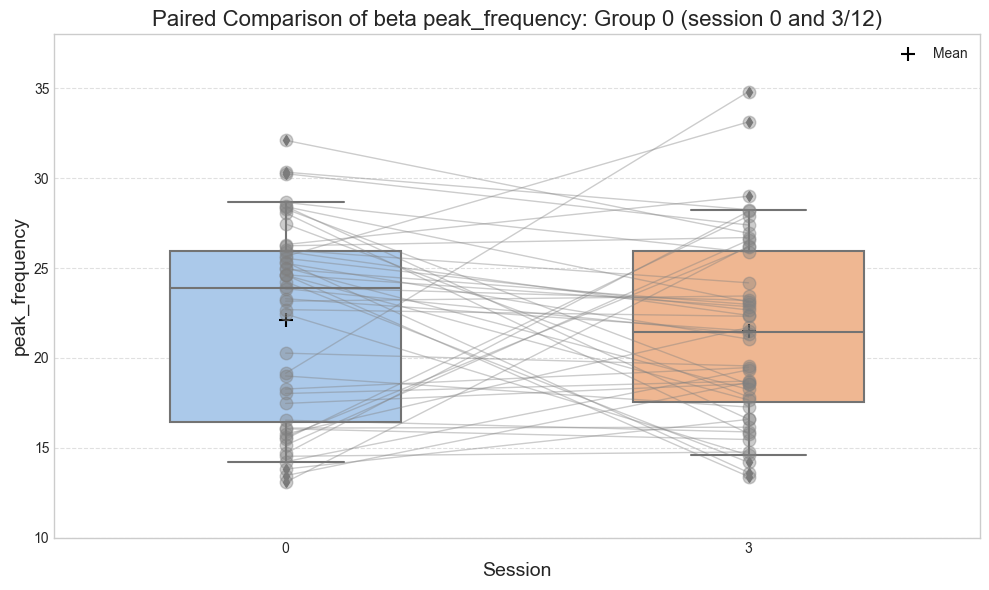

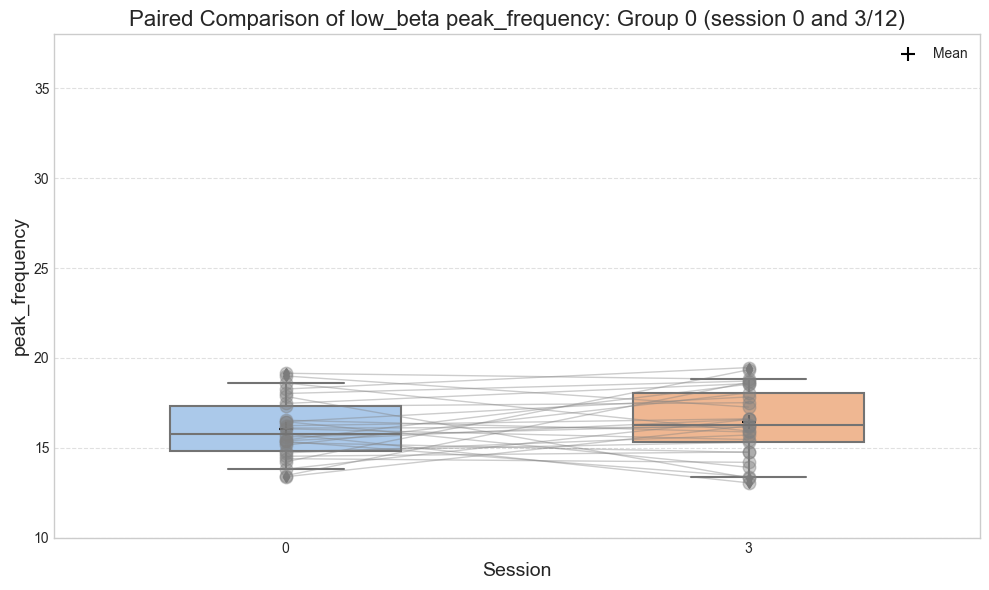

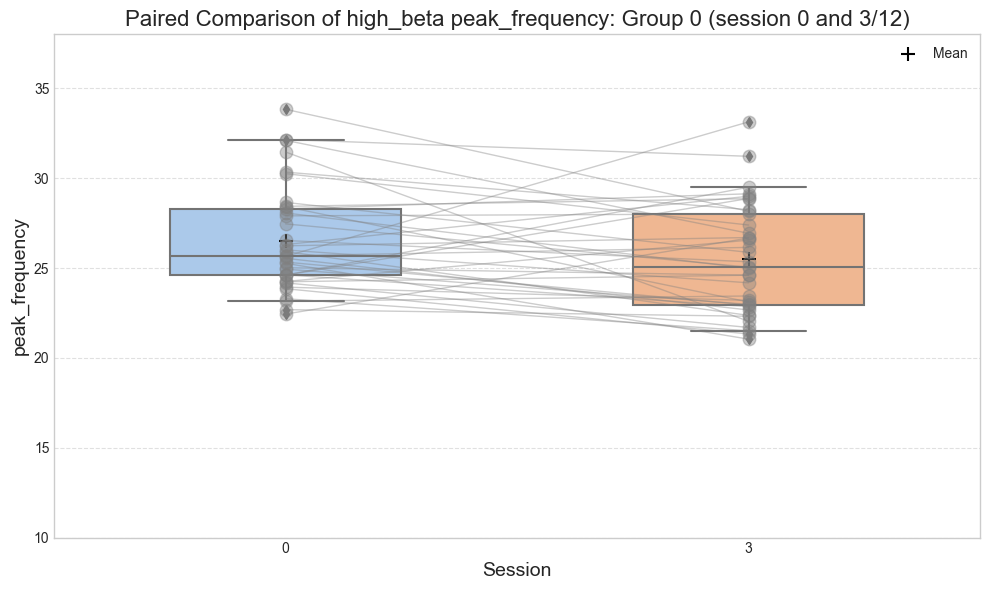

In [265]:
plot_peak_analysis = peak_analysis.boxplot_peak_frequency_or_power_group_0(fooof_spectrum="periodic_spectrum", highest_beta_session="highest_fu3m",
                                                                           peak_feature="peak_frequency")

### Group 0: Peak Power (fixed frequency range or peak per session)

In [266]:
# choose between peak features: peak_power_auc_fixed_f_range, peak_power_auc_at_each_session

peak_CF_0vs3_analyisis = peak_analysis.analyze_peak_frequency_or_power_group_0(
    fooof_spectrum="periodic_spectrum",
    highest_beta_session="highest_fu3m",
    peak_feature="peak_power_auc_fixed_f_range"
)

The center frequency of session 3 was taken for every session to calculate AUC
no low beta peak
no low beta peak
The center frequency of session 3 was taken for every session to calculate AUC
The center frequency of session 3 was taken for every session to calculate AUC
The center frequency of session 3 was taken for every session to calculate AUC
The center frequency of session 3 was taken for every session to calculate AUC
no low beta peak
no low beta peak
The center frequency of session 3 was taken for every session to calculate AUC
no low beta peak
no low beta peak
The center frequency of session 3 was taken for every session to calculate AUC
The center frequency of session 3 was taken for every session to calculate AUC
The center frequency of session 3 was taken for every session to calculate AUC
The center frequency of session 3 was taken for every session to calculate AUC
The center frequency of session 3 was taken for every session to calculate AUC
The center frequency of sessi

In [267]:
peak_CF_0vs3_analyisis[0]

,beta_range,Sample Size,Normal Distribution (p > 0.05),Mean Difference,Standard Deviation,1st Quartile,Median,3rd Quartile,Test Name,Test Statistic,P-value,valid_subjects,P-value (bonferroni),P-value (holm),P-value (fdr_bh)
0,beta,48,False,-7.294825,8.674713,-9.664839,-3.546985,-1.842607,Paired Wilcoxon signed-rank test,0.0,7.105427e-15,"Index(['024_Right', '052_Left', '055_Left', '0...",2.131628e-14,2.131628e-14,2.131628e-14
0,low_beta,29,False,-8.846762,10.464890,-12.321334,-4.920593,-2.077716,Paired Wilcoxon signed-rank test,0.0,3.725290e-09,"Index(['024_Left', '069_Right', '061_Left', '0...",1.117587e-08,3.725290e-09,3.725290e-09
0,high_beta,37,False,-4.101814,4.075422,-6.038147,-3.018158,-1.454559,Paired Wilcoxon signed-rank test,0.0,1.455192e-11,"Index(['024_Right', '049_Left', '024_Left', '0...",4.365575e-11,2.910383e-11,2.182787e-11


In [268]:
data = peak_CF_0vs3_analyisis[0]
pval = data["P-value (fdr_bh)"].values

# write each pval as float with 12 decimals
pval = [f'{x:.12f}' for x in pval]
pval

['0.000000000000', '0.000000003725', '0.000000000022']

In [251]:
peak_CF_0vs3_analyisis[0].valid_subjects.values

array([Index(['024_Right', '052_Left', '055_Left', '059_Right', '059_Left',
              '060_Right', '060_Left', '061_Left', '062_Right', '062_Left',
              '063_Right', '065_Right', '065_Left', '066_Left', '069_Right',
              '069_Left', '072_Right', '072_Left', '075_Right', '075_Left',
              '081_Right', '081_Left', '084_Right', '024_Left', '055_Right',
              '052_Right', '049_Left', '025_Right', '025_Left', '026_Right',
              '026_Left', '028_Right', '028_Left', '029_Right', '029_Left',
              '030_Right', '030_Left', '031_Right', '031_Left', '032_Right',
              '032_Left', '038_Right', '038_Left', '047_Right', '047_Left',
              '048_Left', '049_Right', '084_Left'],
             dtype='object', name='subject_hemisphere')                     ,
       Index(['024_Left', '069_Right', '061_Left', '065_Right', '065_Left',
              '059_Left', '059_Right', '055_Left', '025_Right', '052_Left',
              '052_Right', '04

In [252]:
peak_CF_0vs3_analyisis[1]["beta"]

,subject_hemisphere,session,bipolar_channel,beta_center_frequency
1,048_Right,0,01,NaN
0,061_Right,0,12,NaN
2,063_Left,0,23,NaN
1,066_Right,0,01,NaN


The center frequency of the beta peak was taken from each session independently to calculate AUC.
The center frequency of the beta peak was taken from each session independently to calculate AUC.
The center frequency of the beta peak was taken from each session independently to calculate AUC.
The center frequency of the beta peak was taken from each session independently to calculate AUC.
The center frequency of the beta peak was taken from each session independently to calculate AUC.
The center frequency of the beta peak was taken from each session independently to calculate AUC.
The center frequency of the beta peak was taken from each session independently to calculate AUC.
The center frequency of the beta peak was taken from each session independently to calculate AUC.
The center frequency of the beta peak was taken from each session independently to calculate AUC.
The center frequency of the beta peak was taken from each session independently to calculate AUC.
The center frequency

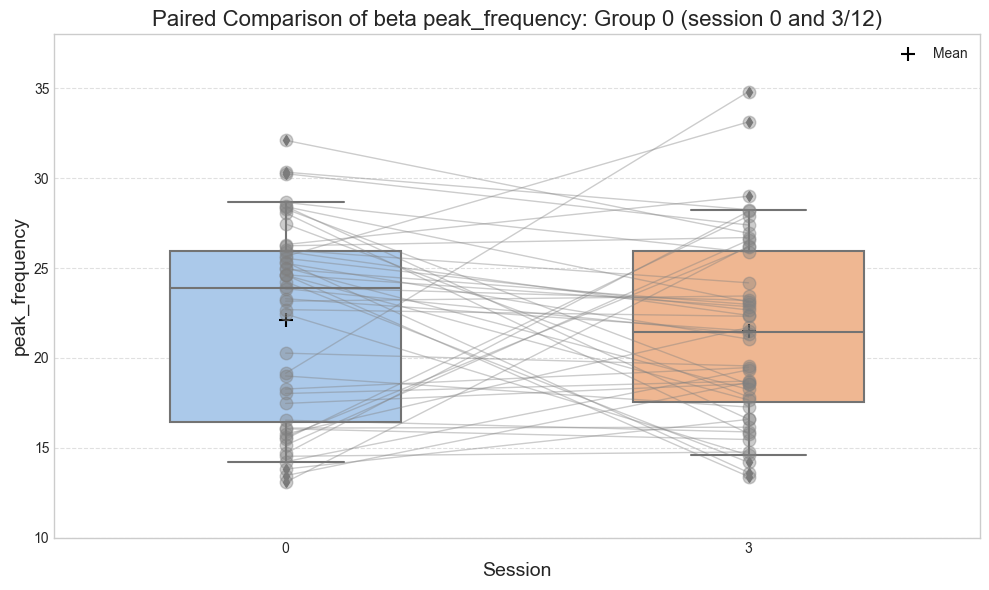

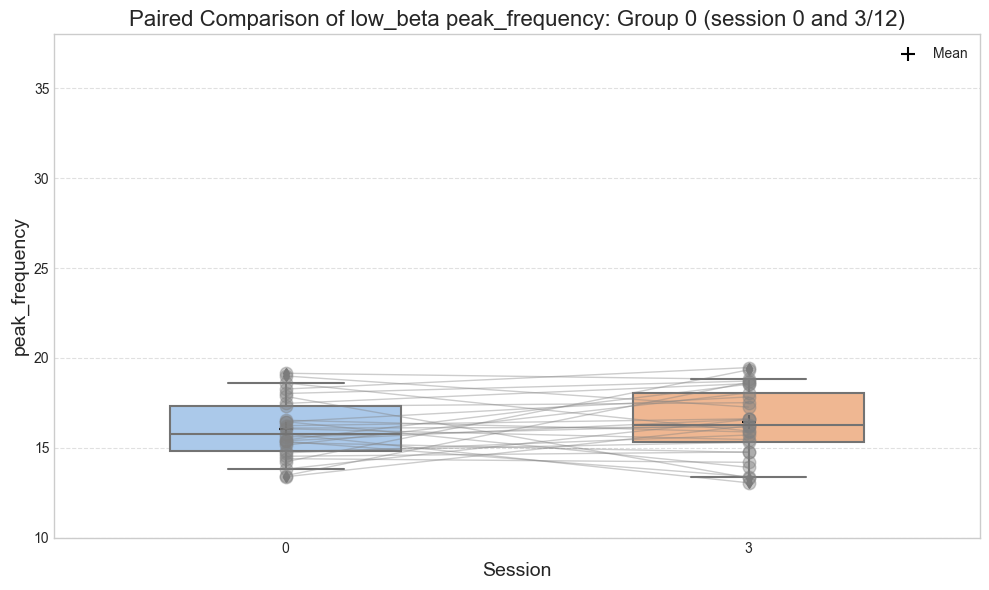

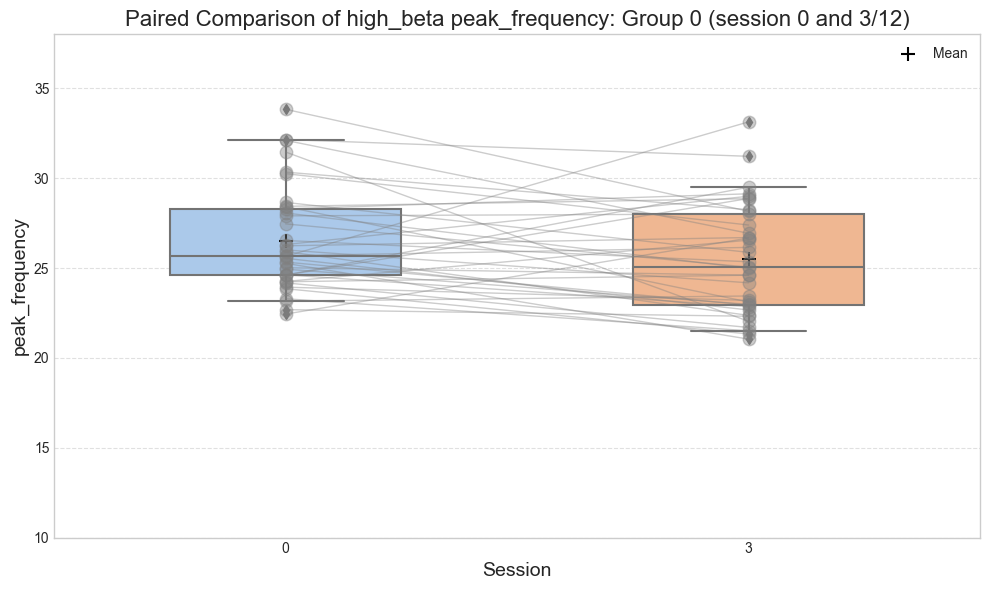

In [263]:
plot_peak_analysis = peak_analysis.boxplot_peak_frequency_or_power_group_0(fooof_spectrum="periodic_spectrum", highest_beta_session="highest_fu3m",
                                                                           peak_feature="peak_frequency")

### Peak analysis between 3 sessions (group_1 and group_2)

In [424]:
multiple_sessions_peak_analysis = peak_analysis.analyze_peak_frequency_or_power_three_sessions(fooof_spectrum="periodic_spectrum",
                                                                            highest_beta_session="highest_fu3m", 
                                                                            peak_feature="peak_power_auc_per_peak", 
                                                                            cohort="group_2")

The center frequency of the beta peak was taken from each session independently to calculate AUC.
The center frequency of the beta peak was taken from each session independently to calculate AUC.
The center frequency of the beta peak was taken from each session independently to calculate AUC.
The center frequency of the beta peak was taken from each session independently to calculate AUC.
The center frequency of the beta peak was taken from each session independently to calculate AUC.
The center frequency of the beta peak was taken from each session independently to calculate AUC.
The center frequency of the beta peak was taken from each session independently to calculate AUC.
The center frequency of the beta peak was taken from each session independently to calculate AUC.
The center frequency of the beta peak was taken from each session independently to calculate AUC.
The center frequency of the beta peak was taken from each session independently to calculate AUC.
The center frequency

In [425]:
multiple_sessions_peak_analysis[5]

,Frequency Range,Session,Mean,Median,1st Quartile,3rd Quartile,Standard Deviation,Sample Size
0,beta,0,10.060450,3.319937,1.785400,10.097556,14.328207,23
1,beta,1,6.408352,1.961445,0.616889,5.970201,9.651200,23
2,beta,2,6.120254,2.826502,0.781586,5.614182,9.398505,23
3,low_beta,0,24.130013,20.399579,7.649537,41.884228,20.453532,6
4,low_beta,1,15.880738,15.567529,5.811033,23.581240,13.297442,6
5,low_beta,2,13.468208,6.178146,3.625582,23.998122,14.986001,6
6,high_beta,0,4.913999,2.613320,1.510252,5.642118,6.307953,23
7,high_beta,1,3.457237,1.961445,0.616889,4.136241,4.901641,23
8,high_beta,2,3.382577,0.921992,0.506019,3.973371,4.612528,23


In [428]:
multiple_sessions_peak_analysis[0]

,beta_range,Sample Size,Normal Distribution (p > 0.05),Test Name,Test Statistic,P-value
0,beta,23,False,Friedman test,9.739130,0.007677
0,low_beta,6,False,Friedman test,6.333333,0.042144
0,high_beta,23,False,Friedman test,5.478261,0.064627


In [429]:
# post-hoc results only for significant main test!!! if not significant, no post-hoc tests are performed
multiple_sessions_peak_analysis[1] 


,Fq_range,Comparison,Raw P-value,Corrected P-value (bonferroni),Corrected P-value (holm),Corrected P-value (fdr_bh)
0,beta,beta: 0 vs 1,0.010109,0.030328,0.030328,0.030328
1,beta,beta: 0 vs 2,0.038380,0.115140,0.076760,0.057570
2,beta,beta: 1 vs 2,0.222615,0.667846,0.222615,0.222615
3,low_beta,low_beta: 0 vs 1,0.062500,0.187500,0.125000,0.093750
4,low_beta,low_beta: 0 vs 2,0.031250,0.093750,0.093750,0.093750
5,low_beta,low_beta: 1 vs 2,1.000000,1.000000,1.000000,1.000000


In [423]:
data = multiple_sessions_peak_analysis[1] 
pval = data["Corrected P-value (fdr_bh)"].values

# write each pval as float with 12 decimals
pval = [f'{x:.12f}' for x in pval]
pval

['0.006407976151',
 '0.013719320297',
 '1.000000000000',
 '0.018441796303',
 '0.018441796303',
 '0.846231698990']

In [418]:
multiple_sessions_peak_analysis[2]["beta"]

,subject_hemisphere,session,bipolar_channel,beta_center_frequency
1,026_Left,12,01,NaN


In [415]:
multiple_sessions_peak_analysis[3]["high_beta"]

,0,1,2
subject_hemisphere,,,
017_Left,30.461935,23.663613,22.912759
017_Right,29.434382,28.747068,33.098769
019_Left,29.913429,30.861338,31.234454
019_Right,28.498156,31.551690,31.197454
021_Left,28.528614,28.592608,26.067657
021_Right,28.124878,28.356136,27.535636
024_Left,21.692757,22.466970,21.308614
024_Right,21.507007,34.754558,23.725636
026_Right,27.898970,24.773851,27.522676


In [357]:
multiple_sessions_peak_analysis[4]

{'beta': [],
 'low_beta': [0.267578125, 0.013427734375, 0.067626953125],
 'high_beta': []}

In [358]:
multiple_sessions_peak_analysis[4]

{'beta': [],
 'low_beta': [0.267578125, 0.013427734375, 0.067626953125],
 'high_beta': []}

The center frequency of the beta peak was taken from each session independently to calculate AUC.
The center frequency of the beta peak was taken from each session independently to calculate AUC.
The center frequency of the beta peak was taken from each session independently to calculate AUC.
The center frequency of the beta peak was taken from each session independently to calculate AUC.
The center frequency of the beta peak was taken from each session independently to calculate AUC.
The center frequency of the beta peak was taken from each session independently to calculate AUC.
The center frequency of the beta peak was taken from each session independently to calculate AUC.
The center frequency of the beta peak was taken from each session independently to calculate AUC.
The center frequency of the beta peak was taken from each session independently to calculate AUC.
The center frequency of the beta peak was taken from each session independently to calculate AUC.
The center frequency

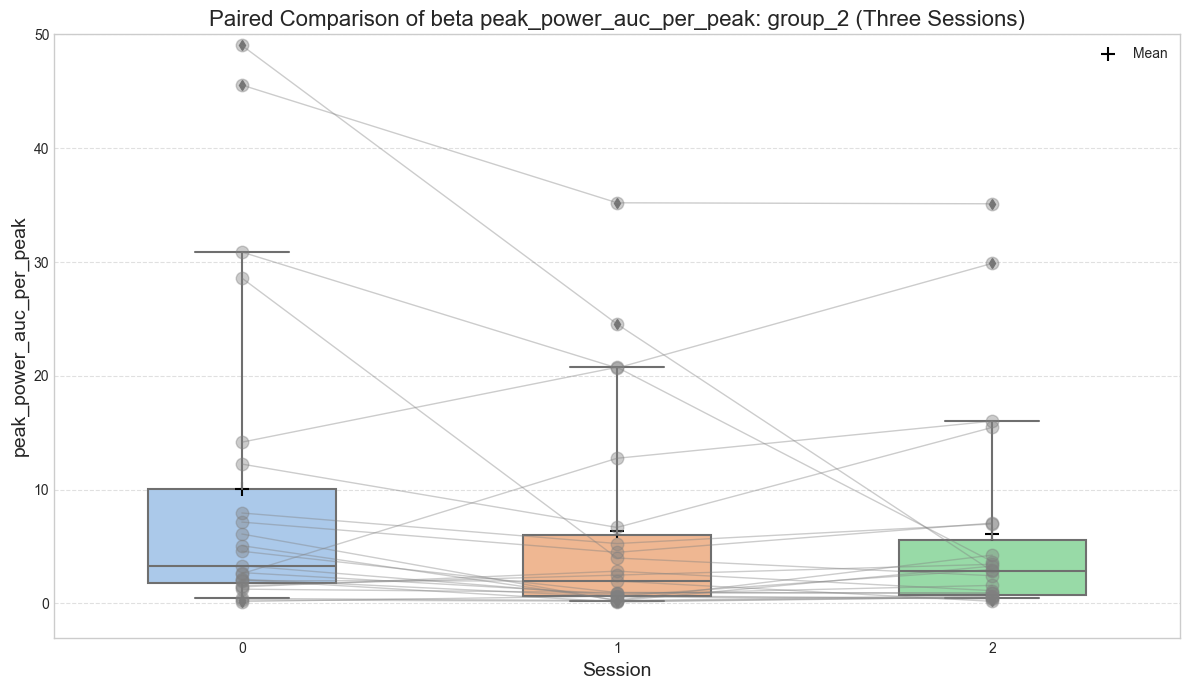

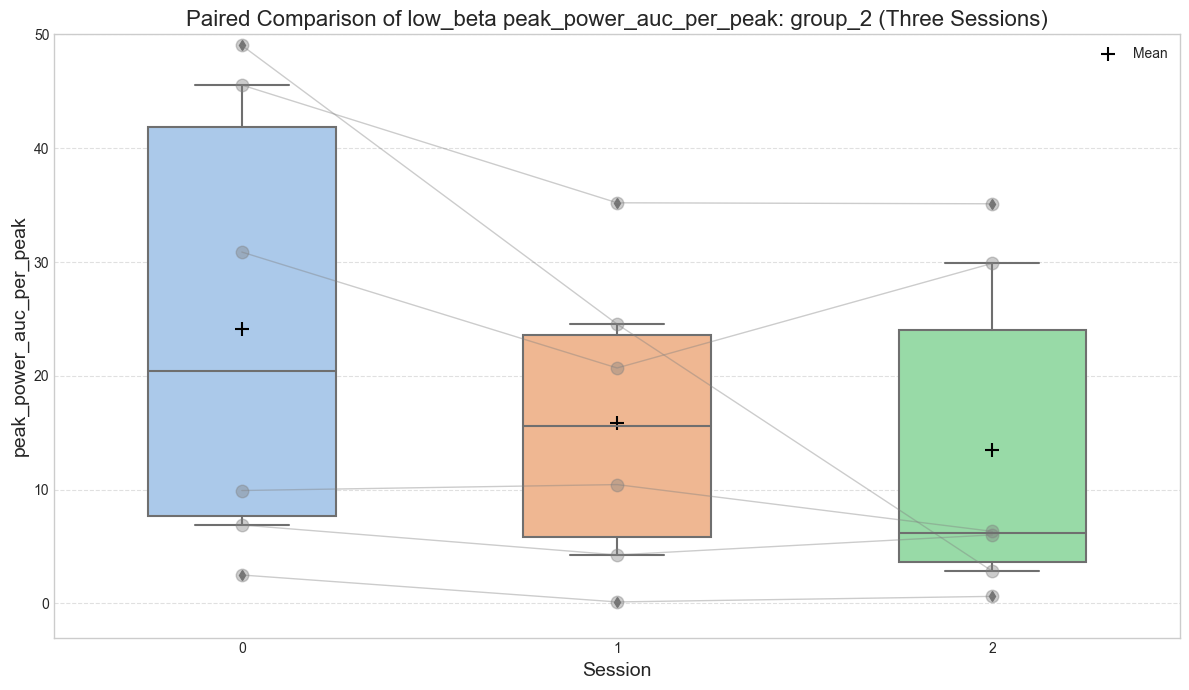

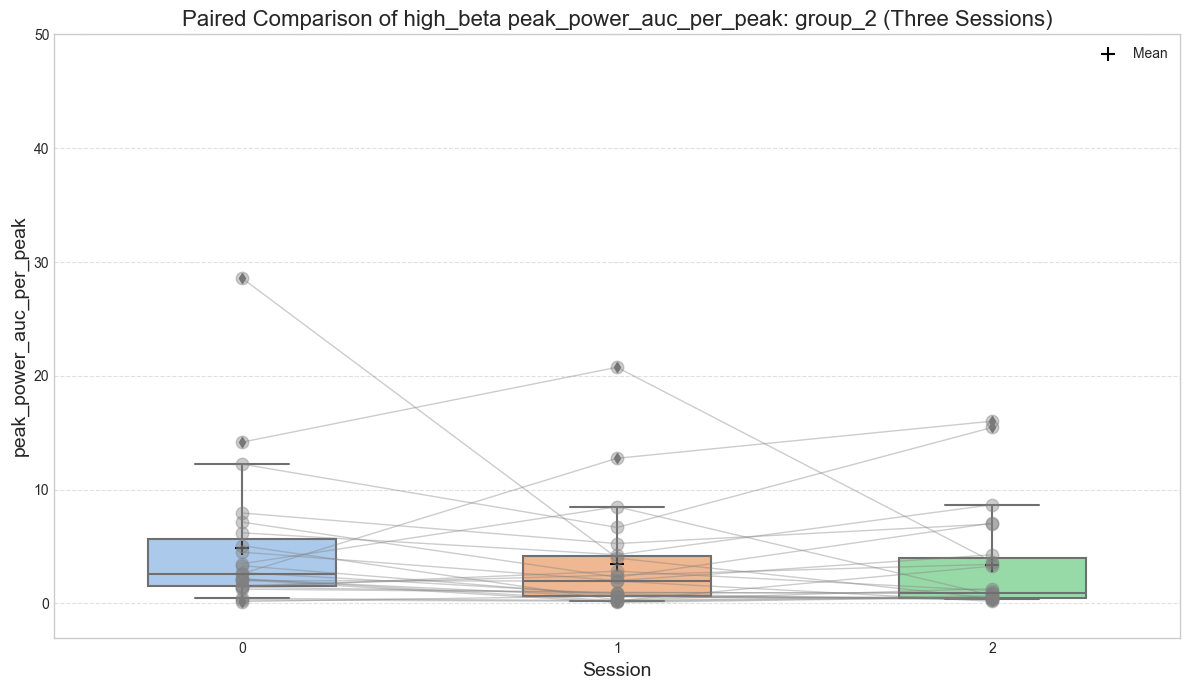

In [430]:
plot_three_sessions = peak_analysis.boxplot_peak_frequency_or_power_three_sessions(fooof_spectrum="periodic_spectrum", highest_beta_session="highest_fu3m",
                                                                     peak_feature="peak_power_auc_per_peak",cohort="group_2")

### Peak shift > 2.5 / 5 Hz (3 sessions)

### Old code

The center frequency of session 3 was taken for every session to calculate AUC
no low beta peak
no low beta peak
no low beta peak
The center frequency of session 3 was taken for every session to calculate AUC
The center frequency of session 3 was taken for every session to calculate AUC
The center frequency of session 3 was taken for every session to calculate AUC
The center frequency of session 3 was taken for every session to calculate AUC
no low beta peak
no low beta peak
no low beta peak
The center frequency of session 3 was taken for every session to calculate AUC
no low beta peak
no low beta peak
no low beta peak
The center frequency of session 3 was taken for every session to calculate AUC
The center frequency of session 3 was taken for every session to calculate AUC
The center frequency of session 3 was taken for every session to calculate AUC
The center frequency of session 3 was taken for every session to calculate AUC
The center frequency of session 3 was taken for every ses

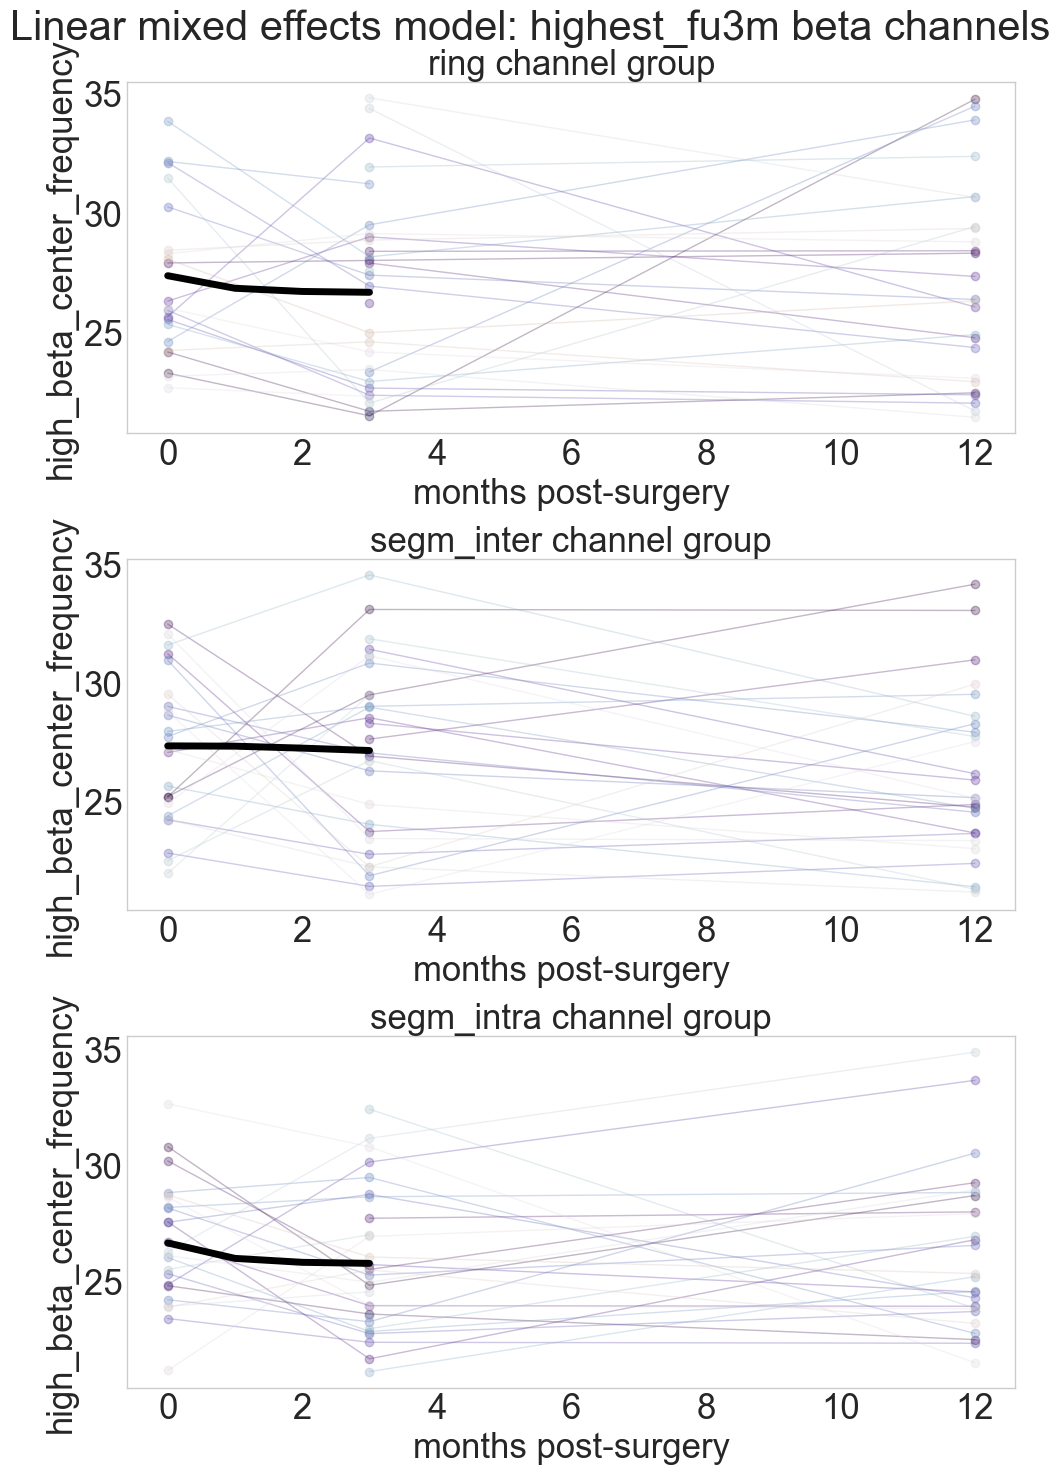

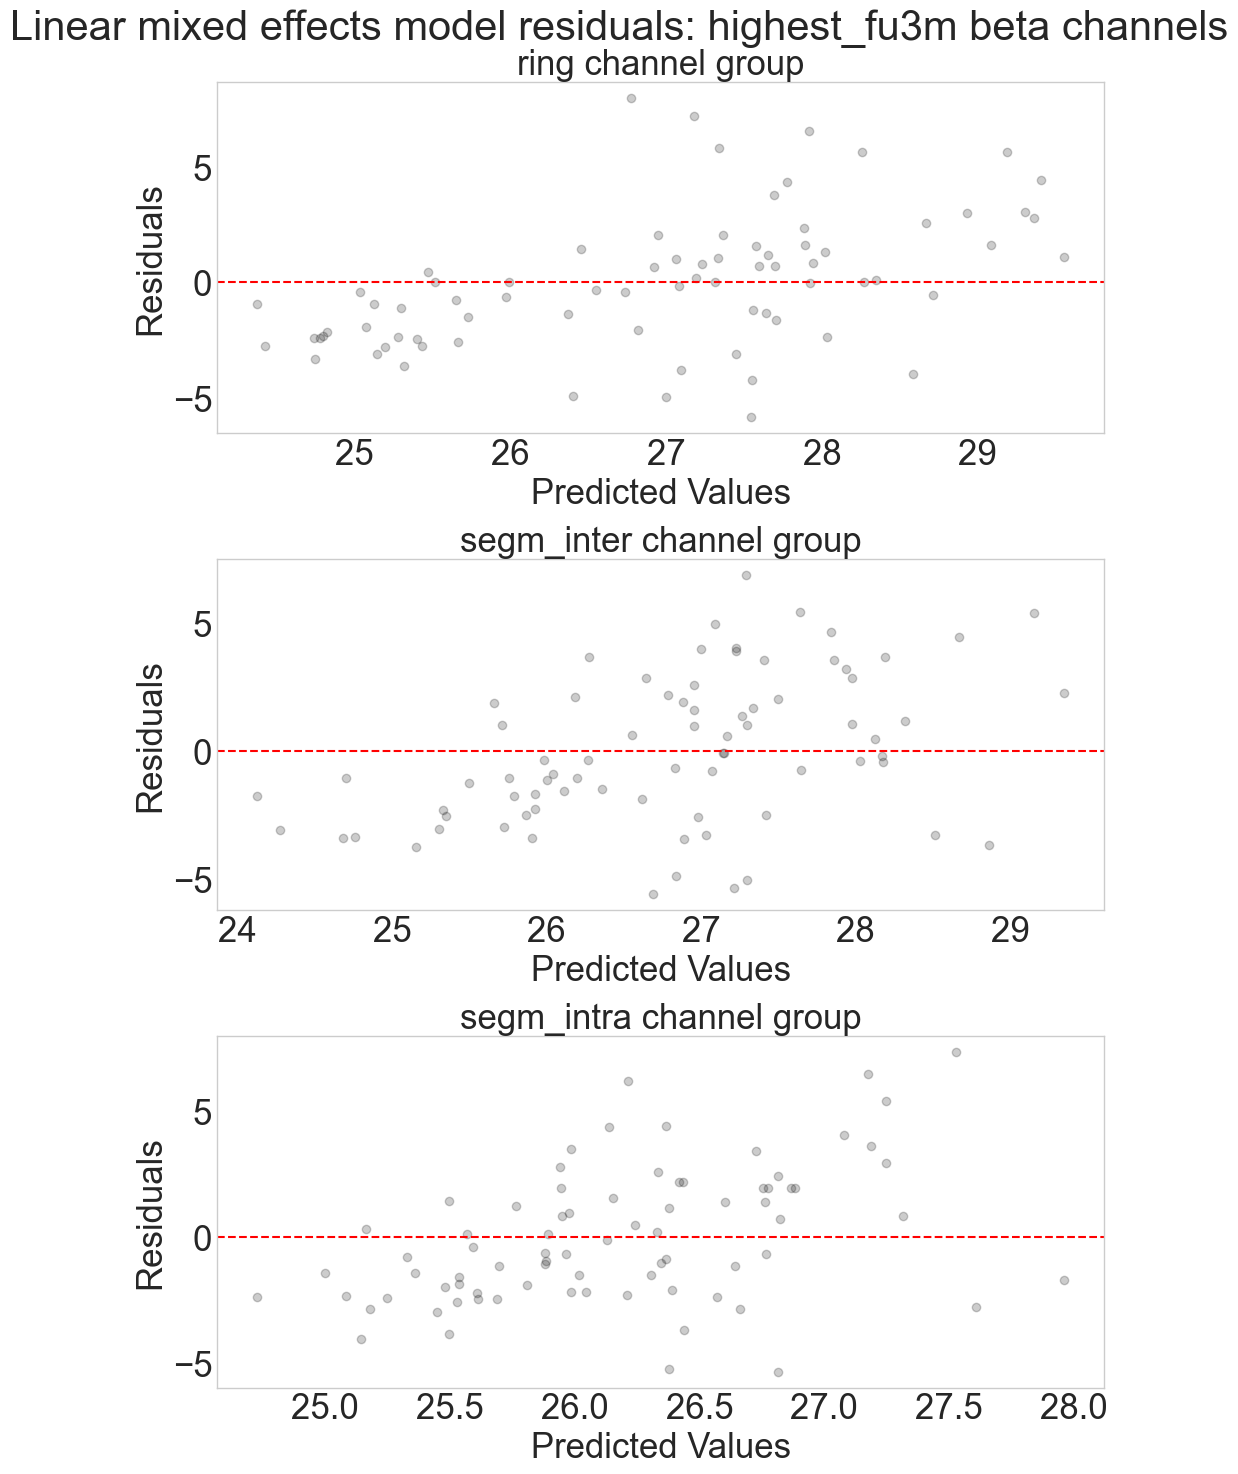

In [73]:
lme_highest_beta_channels = fooof_peaks.fooof_mixedlm_highest_beta_channels(
    fooof_spectrum="periodic_spectrum",
    fooof_version="v2",
    around_cf="around_cf_at_fixed_session",
    highest_beta_session="highest_fu3m",
    data_to_fit="high_beta_center_frequency",
    incl_sessions=[0,3,12],
    shape_of_model="asymptotic",
    cohort="group_1"
)

In [ ]:
# group 1 -> RING: BETA 3MFU n=30, postop n=27, 12MFU n=28 
# group 1 -> RING: HIGH BETA 3MFU n=30, postop n=21, 12MFU n=25
lme_highest_beta_channels["sample_size_df"]

,channel_group,session,count
ring_0mfu,ring,0,21
ring_3mfu,ring,3,30
ring_12mfu,ring,12,25
segm_inter_0mfu,segm_inter,0,23
segm_inter_3mfu,segm_inter,3,28
segm_inter_12mfu,segm_inter,12,26
segm_intra_0mfu,segm_intra,0,23
segm_intra_3mfu,segm_intra,3,29
segm_intra_12mfu,segm_intra,12,26


In [ ]:
# group 2 -> RING: 3MFU n=24, 12MFU one peak missing, 18MFU n=24 complete
lme_highest_beta_channels["sample_size_df"]

,channel_group,session,count
ring_3mfu,ring,3,24
ring_12mfu,ring,12,23
ring_18mfu,ring,18,24
segm_inter_3mfu,segm_inter,3,24
segm_inter_12mfu,segm_inter,12,24
segm_inter_18mfu,segm_inter,18,23
segm_intra_3mfu,segm_intra,3,24
segm_intra_12mfu,segm_intra,12,24
segm_intra_18mfu,segm_intra,18,24
